# FarmTech Solutions — Fase 5, Entrega 1
## Análise exploratória, clusterização, outliers e regressão do rendimento de safra

**Status deste notebook: versão de desenvolvimento (Etapa 1), executada de ponta a ponta.**

> ⚠️ **Renomeação obrigatória antes da entrega.** O enunciado exige que o arquivo contenha
> nome completo, RM e o sufixo `pbl_fase4.ipynb` (exemplo: `JoaoSantos_rm76332_pbl_fase4.ipynb`).
> Enquanto os nomes e RMs do grupo não estiverem confirmados, o arquivo permanece como
> `farmtech_desenvolvimento.ipynb`. **Esta pendência é do coordenador.**

### O que este notebook cobre

| Seção | Conteúdo | Situação |
| --- | --- | --- |
| 1 | Ambiente, semente e caminhos | executado |
| 2 | Carga, integridade e inventário da base | executado |
| 3 | Contrato de dados e identificador de cenário | executado |
| 4 | Divisão treino/teste por cenário e validação cruzada agrupada | executado |
| 5 | Análise exploratória (EDA) | executado |
| 6 | Clusterização de cenários climáticos | executado |
| 7 | Investigação de outliers | executado |
| 8 | Comparação inicial dos cinco regressores | executado |
| 9 | Avaliação no teste reservado | **pendente por decisão de protocolo** (ver seção 9) |
| 10 | Conclusões, limitações e pendências | executado |

### Decisões metodológicas em linguagem simples

1. **Cada combinação climática aparece quatro vezes na base**, uma vez por cultura. Se essas
   quatro linhas fossem separadas entre treino e teste, o modelo veria no treino exatamente as
   mesmas condições de clima que encontraria no teste. Para medir se o modelo generaliza para
   condições climáticas novas, mantemos cada combinação inteira de um lado só da divisão.
2. **A cultura explica quase toda a variação do rendimento.** O dendê rende cerca de vinte
   vezes mais, nas unidades do arquivo, do que o cacau. Por isso um R² alto no conjunto todo não
   prova nada: ele só mostra que o modelo aprendeu a distinguir culturas. A pergunta que interessa
   é se o clima acrescenta informação **dentro de cada cultura**, e é assim que comparamos os modelos.
3. **Não convertemos unidades.** O enunciado descreve o rendimento em toneladas por hectare,
   mas os valores do CSV (de 5.249 a 203.399) não são compatíveis com essa leitura. Mantemos os
   números originais e reportamos os erros na mesma unidade do arquivo. Ver seção 3.3.

In [1]:
# ============================================================
# 1. AMBIENTE, SEMENTE E CAMINHOS
# ============================================================
import hashlib          # hash SHA-256 para verificar a integridade do CSV
import json             # serializacao do registro do protocolo
import sys              # versao do interpretador Python
import warnings         # controle das mensagens de aviso
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

# Semente unica do projeto: todo procedimento aleatorio que aceite semente usa esta constante.
SEED = 42
np.random.seed(SEED)

# Silencia apenas avisos de conveniencia de bibliotecas; erros continuam visiveis.
warnings.filterwarnings("ignore", category=FutureWarning)

# Padroes de exibicao para que as tabelas caibam na largura da pagina.
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

print("Python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("matplotlib  ", matplotlib.__version__)
print("seaborn     ", sns.__version__)

Python       3.12.10
numpy        2.3.3
pandas       2.3.2
scikit-learn 1.7.1
matplotlib   3.10.6
seaborn      0.13.2


In [2]:
def encontrar_raiz(inicio=None):
    """Sobe na arvore de diretorios ate achar a pasta que contem data/crop_yield.csv.

    Assim o notebook funciona tanto executado de dentro de notebooks/ quanto da raiz
    do projeto, sempre com caminhos relativos.
    """
    atual = Path(inicio or Path.cwd()).resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "data" / "crop_yield.csv").exists():
            return candidato
    raise FileNotFoundError("data/crop_yield.csv nao encontrado a partir de " + str(atual))


RAIZ = encontrar_raiz()                           # raiz do projeto
CAMINHO_CSV = RAIZ / "data" / "crop_yield.csv"    # base original, nunca sobrescrita
DIR_FIGURAS = RAIZ / "docs" / "figuras"           # destino das figuras exportadas
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

print("Raiz do projeto:", RAIZ)
print("CSV            :", CAMINHO_CSV.relative_to(RAIZ))
print("Figuras        :", DIR_FIGURAS.relative_to(RAIZ))

Raiz do projeto: C:\Users\lcordeiro\GitHub\fase5-cap1-farmtech
CSV            : data\crop_yield.csv
Figuras        : docs\figuras


In [3]:
# Estilo visual unico para todas as figuras do notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,                       # legibilidade na tela
    "savefig.dpi": 150,                      # qualidade dos arquivos exportados
    "figure.constrained_layout.use": True,   # evita rotulos cortados
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "font.size": 10,
})

# Paleta fixa por cultura, usada em todas as figuras para facilitar a leitura comparada.
CORES_CULTURA = {
    "Cocoa, beans":    "#8C6239",   # marrom
    "Oil palm fruit":  "#E1A100",   # ambar
    "Rice, paddy":     "#2E8B57",   # verde
    "Rubber, natural": "#4C6EF5",   # azul
}

# Rotulos curtos para os eixos, evitando texto cortado nas figuras.
ROTULO_CURTO = {
    "Cocoa, beans": "Cacau",
    "Oil palm fruit": "Dende",
    "Rice, paddy": "Arroz",
    "Rubber, natural": "Borracha",
}

ROTULO_CLIMA = {
    "precipitacao": "Precipitacao",
    "umidade_especifica": "Umidade especifica",
    "umidade_relativa": "Umidade relativa",
    "temperatura": "Temperatura",
}


def salvar_figura(fig, nome):
    """Exporta a figura para docs/figuras/ com margem folgada, para reuso no README e no video."""
    destino = DIR_FIGURAS / (nome + ".png")
    fig.savefig(destino, bbox_inches="tight", facecolor="white")
    print("figura salva:", destino.relative_to(RAIZ))

---
# 2. Carga, verificação de integridade e inventário

O CSV original permanece intacto em `data/crop_yield.csv`. Registramos o hash SHA-256 do arquivo
para que qualquer integrante confirme que está trabalhando exatamente sobre a mesma base.

In [4]:
# ============================================================
# 2. CARGA E VERIFICACAO DE INTEGRIDADE
# ============================================================
BYTES_CSV = CAMINHO_CSV.read_bytes()                       # leitura binaria para o hash
HASH_CSV = hashlib.sha256(BYTES_CSV).hexdigest().upper()   # impressao digital do arquivo
HASH_ESPERADO = "07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B"

bruto = pd.read_csv(CAMINHO_CSV)   # DataFrame com os nomes de coluna originais

print("SHA-256 do arquivo :", HASH_CSV)
print("SHA-256 esperado   :", HASH_ESPERADO)
print("Integridade        :", "OK" if HASH_CSV == HASH_ESPERADO else "DIVERGENTE - conferir a origem do CSV")
print("")
print("Dimensoes          :", bruto.shape[0], "linhas x", bruto.shape[1], "colunas")
print("Tamanho            :", format(len(BYTES_CSV), ","), "bytes")
print("")
print("Colunas originais:")
for i, coluna in enumerate(bruto.columns, start=1):
    print("  " + str(i) + ".", coluna)

SHA-256 do arquivo : 07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B
SHA-256 esperado   : 07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B
Integridade        : OK

Dimensoes          : 156 linhas x 6 colunas
Tamanho            : 7,606 bytes

Colunas originais:
  1. Crop
  2. Precipitation (mm day-1)
  3. Specific Humidity at 2 Meters (g/kg)
  4. Relative Humidity at 2 Meters (%)
  5. Temperature at 2 Meters (C)
  6. Yield


In [5]:
# Inventario de qualidade: tipos, nulos, valores distintos e amostra de valores.
inventario = pd.DataFrame({
    "tipo": bruto.dtypes.astype(str),
    "nao_nulos": bruto.notna().sum(),
    "nulos": bruto.isna().sum(),
    "distintos": bruto.nunique(),
    "exemplo": [bruto[c].iloc[0] for c in bruto.columns],
})
print("=== Inventario das colunas ===")
display(inventario)

# Duplicatas: linhas identicas em todas as colunas.
print("")
print("Linhas completamente duplicadas:", int(bruto.duplicated().sum()))
print("Total de celulas vazias        :", int(bruto.isna().sum().sum()))

=== Inventario das colunas ===


,tipo,nao_nulos,nulos,distintos,exemplo
Crop,object,156,0,4,"Cocoa, beans"
Precipitation (mm day-1),float64,156,0,39,2248.92
Specific Humidity at 2 Meters (g/kg),float64,156,0,33,17.72
Relative Humidity at 2 Meters (%),float64,156,0,38,83.4
Temperature at 2 Meters (C),float64,156,0,29,26.01
Yield,int64,156,0,155,11560



Linhas completamente duplicadas: 0
Total de celulas vazias        : 0


### 2.1 Achados do inventário

- **156 linhas e 6 colunas**, sem nenhuma célula vazia e sem nenhuma linha completamente duplicada.
- Uma coluna categórica (`Crop`), quatro colunas climáticas numéricas e a coluna alvo `Yield`.
- **Não existe coluna de data, de local nem de identificação de fazenda.** Portanto não é possível
  afirmar que os registros correspondem a anos, safras ou talhões específicos. Qualquer leitura
  temporal seria suposição nossa, não informação da base.

---
# 3. Contrato de dados

Esta seção implementa o mesmo protocolo descrito em [`docs/CONTRATO_DADOS.md`](../docs/CONTRATO_DADOS.md).
Ele existe para que a frente ML reproduza exatamente a mesma divisão e as mesmas partições ao
desenvolver os modelos, e para que o restante do grupo saiba o que cada nome interno significa.

In [6]:
# ============================================================
# 3. CONTRATO DE DADOS
# ============================================================
# Mapeamento dos nomes originais do CSV para nomes internos curtos e sem acento.
RENOMEAR = {
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)": "umidade_especifica",
    "Relative Humidity at 2 Meters (%)": "umidade_relativa",
    "Temperature at 2 Meters (C)": "temperatura",
    "Yield": "rendimento",
}

VAR_CLIMA = ["precipitacao", "umidade_especifica", "umidade_relativa", "temperatura"]  # entradas numericas
VAR_CATEGORICA = ["cultura"]     # entrada categorica
ALVO = "rendimento"              # variavel a prever

dados = bruto.rename(columns=RENOMEAR).copy()   # copia de trabalho; o CSV original nao e alterado

# Dicionario de dados exibido no relatorio.
dicionario = pd.DataFrame([
    ("Crop", "cultura", "categorica", "-", "Nome da cultura agricola. 4 categorias."),
    ("Precipitation (mm day-1)", "precipitacao", "numerica", "mm/dia (declarada)", "Chuva. Ver duvida de unidade em 3.3."),
    ("Specific Humidity at 2 Meters (g/kg)", "umidade_especifica", "numerica", "g/kg", "Vapor de agua por kg de ar seco a 2 m."),
    ("Relative Humidity at 2 Meters (%)", "umidade_relativa", "numerica", "%", "Umidade relativa a 2 m."),
    ("Temperature at 2 Meters (C)", "temperatura", "numerica", "graus C", "Temperatura do ar a 2 m."),
    ("Yield", "rendimento", "numerica", "t/ha (declarada)", "ALVO. Ver duvida de unidade em 3.3."),
], columns=["nome_original", "nome_interno", "tipo", "unidade_declarada", "descricao"])
display(dicionario)

,nome_original,nome_interno,tipo,unidade_declarada,descricao
0,Crop,cultura,categorica,-,Nome da cultura agricola. 4 categorias.
1,Precipitation (mm day-1),precipitacao,numerica,mm/dia (declarada),Chuva. Ver duvida de unidade em 3.3.
2,Specific Humidity at 2 Meters (g/kg),umidade_especifica,numerica,g/kg,Vapor de agua por kg de ar seco a 2 m.
3,Relative Humidity at 2 Meters (%),umidade_relativa,numerica,%,Umidade relativa a 2 m.
4,Temperature at 2 Meters (C),temperatura,numerica,graus C,Temperatura do ar a 2 m.
5,Yield,rendimento,numerica,t/ha (declarada),ALVO. Ver duvida de unidade em 3.3.


## 3.1 Estrutura escondida da base: cada cenário climático aparece quatro vezes

Antes de qualquer modelagem é preciso entender como as linhas se relacionam entre si. A verificação
abaixo mostra que as quatro variáveis climáticas formam apenas **39 combinações distintas**, e que
cada combinação aparece **exatamente quatro vezes** — uma vez para cada cultura.

In [7]:
def identificador_cenario(linha):
    """Gera um identificador deterministico a partir apenas das quatro variaveis climaticas.

    O identificador NAO usa a cultura nem o rendimento: ele serve para agrupar linhas que
    descrevem a mesma condicao climatica. E usado para dividir os dados, nunca como entrada
    do modelo. O arredondamento fixo em 6 casas garante o mesmo resultado em qualquer maquina.
    """
    assinatura = "|".join(format(linha[variavel], ".6f") for variavel in VAR_CLIMA)
    return hashlib.sha256(assinatura.encode("utf-8")).hexdigest()[:12]


dados["cenario"] = dados.apply(identificador_cenario, axis=1)

print("Cenarios climaticos distintos :", dados["cenario"].nunique())
print("Linhas por cenario            :", sorted(dados.groupby("cenario").size().unique().tolist()))
print("Culturas por cenario          :", sorted(dados.groupby("cenario")["cultura"].nunique().unique().tolist()))
print("Linhas por cultura            :", dados["cultura"].value_counts().to_dict())

Cenarios climaticos distintos : 39
Linhas por cenario            : [4]
Culturas por cenario          : [4]
Linhas por cultura            : {'Cocoa, beans': 39, 'Oil palm fruit': 39, 'Rice, paddy': 39, 'Rubber, natural': 39}


### 3.2 Por que essa repetição não é duplicata a remover

As quatro linhas de um mesmo cenário **não são cópias**: elas têm rendimentos diferentes, porque
descrevem culturas diferentes sob a mesma condição climática. Remover três delas destruiria a
informação central do problema.

O que a repetição significa para a avaliação é outra coisa: **a base contém apenas 39 condições
climáticas independentes, não 156**. Se dividíssemos as linhas ao acaso, o modelo veria no treino
exatamente o mesmo clima que encontraria no teste, mudando só a cultura. A métrica resultante
mediria a capacidade de memorizar 39 cenários, não a de generalizar para um clima novo.

Por isso adotamos a divisão **por cenário**: cada combinação climática fica inteira em treino ou
inteira em teste.

### 3.3 Dúvida sobre unidades — pendência aberta com a FIAP

O enunciado declara que `Yield` está em **toneladas por hectare**. Os valores do CSV vão de
**5.249 a 203.399**. Uma produtividade de 200 mil toneladas por hectare não tem sentido agronômico
(o dendê, uma das culturas mais produtivas, fica na casa de 10 a 25 t/ha).

O mesmo vale para a precipitação: `Precipitation (mm day-1)` sugere milímetros por dia, mas os
valores vão de **1.934 a 3.086**, faixa compatível com **milímetros por ano**, não por dia.

**Leitura mais provável** (hipótese nossa, não confirmada): `Yield` estaria em hectogramas por
hectare (hg/ha), unidade usada em bases do tipo FAOSTAT — 203.399 hg/ha equivaleria a cerca de
20,3 t/ha para o dendê, valor plausível. E a precipitação seria um acumulado anual.

**Como tratamos isso neste notebook:**

- Mantemos os valores originais, sem nenhuma conversão.
- Reportamos MAE e RMSE **na unidade original do arquivo**, escrita como "un. de rendimento".
- Incluímos o **erro percentual (MAPE)**, que é imune à escolha de unidade e permite comparar
  culturas com magnitudes muito diferentes.
- **Não** escrevemos "t/ha" ao lado das métricas enquanto a unidade não for confirmada.

> **Pendência do coordenador:** confirmar com a FIAP a unidade real de `Yield` e de
> `Precipitation`, e se os 39 cenários correspondem a alguma agregação temporal. Uma vez
> esclarecido, basta ajustar o texto das métricas — nenhum resultado numérico muda.

---
# 4. Divisão treino/teste e validação cruzada agrupada

**Regra fundamental deste projeto:** a divisão é fixada *antes* de qualquer análise orientada pelo
alvo. Tudo o que orienta escolhas preditivas (correlações com o rendimento, clusters, seleção de
modelo, hiperparâmetros) usa **somente o conjunto de desenvolvimento**. O conjunto de teste fica
lacrado até o fechamento, após a revisão da equipe.

In [8]:
# ============================================================
# 4. DIVISAO POR CENARIO
# ============================================================
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

# GroupShuffleSplit reserva 20% dos GRUPOS (cenarios), nao 20% das linhas.
separador = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
idx_desenvolvimento, idx_teste = next(separador.split(dados, groups=dados["cenario"]))

desenvolvimento = dados.iloc[idx_desenvolvimento].reset_index(drop=True)  # usado em TUDO nesta etapa
teste = dados.iloc[idx_teste].reset_index(drop=True)                      # lacrado ate o fechamento

print("=== Divisao por cenario (GroupShuffleSplit, test_size=0.20, random_state=42) ===")
print("Desenvolvimento :", len(desenvolvimento), "linhas |", desenvolvimento["cenario"].nunique(), "cenarios")
print("Teste reservado :", len(teste), "linhas |", teste["cenario"].nunique(), "cenarios")
print("")
print("Culturas no desenvolvimento:", desenvolvimento["cultura"].value_counts().to_dict())
print("Culturas no teste          :", teste["cultura"].value_counts().to_dict())

=== Divisao por cenario (GroupShuffleSplit, test_size=0.20, random_state=42) ===
Desenvolvimento : 124 linhas | 31 cenarios
Teste reservado : 32 linhas | 8 cenarios

Culturas no desenvolvimento: {'Cocoa, beans': 31, 'Oil palm fruit': 31, 'Rice, paddy': 31, 'Rubber, natural': 31}
Culturas no teste          : {'Cocoa, beans': 8, 'Oil palm fruit': 8, 'Rice, paddy': 8, 'Rubber, natural': 8}


In [9]:
# Particoes internas de validacao, definidas SOMENTE sobre o desenvolvimento.
# Todos os algoritmos usarao exatamente estas mesmas particoes.
validacao_cruzada = GroupKFold(n_splits=5)
PARTICOES = list(validacao_cruzada.split(
    desenvolvimento,
    desenvolvimento[ALVO],
    groups=desenvolvimento["cenario"],
))

resumo_particoes = pd.DataFrame([
    {
        "particao": i,
        "linhas_treino": len(tr),
        "linhas_validacao": len(va),
        "cenarios_treino": desenvolvimento.iloc[tr]["cenario"].nunique(),
        "cenarios_validacao": desenvolvimento.iloc[va]["cenario"].nunique(),
    }
    for i, (tr, va) in enumerate(PARTICOES)
])
display(resumo_particoes)

,particao,linhas_treino,linhas_validacao,cenarios_treino,cenarios_validacao
0,0,96,28,24,7
1,1,100,24,25,6
2,2,100,24,25,6
3,3,100,24,25,6
4,4,100,24,25,6


In [10]:
# ------------------------------------------------------------
# Verificacoes de vazamento - devem TODAS passar.
# ------------------------------------------------------------
verificacoes = []

# (a) nenhum cenario aparece ao mesmo tempo em desenvolvimento e teste
comuns = set(desenvolvimento["cenario"]) & set(teste["cenario"])
verificacoes.append(("Nenhum cenario compartilhado entre desenvolvimento e teste",
                     len(comuns) == 0, str(len(comuns)) + " em comum"))

# (b) nenhum cenario aparece ao mesmo tempo em treino e validacao, em nenhuma particao
vazamentos = [len(set(desenvolvimento.iloc[tr]["cenario"]) & set(desenvolvimento.iloc[va]["cenario"]))
              for tr, va in PARTICOES]
verificacoes.append(("Nenhum cenario compartilhado entre treino e validacao",
                     sum(vazamentos) == 0, "por particao: " + str(vazamentos)))

# (c) a soma das partes reproduz a base completa
verificacoes.append(("Desenvolvimento + teste = 156 linhas",
                     len(desenvolvimento) + len(teste) == len(dados),
                     str(len(desenvolvimento)) + " + " + str(len(teste))))

# (d) cada linha do desenvolvimento e validada exatamente uma vez
cobertura = np.zeros(len(desenvolvimento), dtype=int)
for _, va in PARTICOES:
    cobertura[va] += 1
verificacoes.append(("Cada linha validada exatamente 1 vez",
                     bool((cobertura == 1).all()), "contagens: " + str(sorted(set(cobertura.tolist())))))

# (e) as quatro culturas estao presentes em todas as particoes de validacao
culturas_ok = all(desenvolvimento.iloc[va]["cultura"].nunique() == 4 for _, va in PARTICOES)
verificacoes.append(("As 4 culturas aparecem em toda particao de validacao", culturas_ok, ""))

# (f) o CSV original continua com o hash esperado
verificacoes.append(("CSV original preservado (SHA-256)", HASH_CSV == HASH_ESPERADO, HASH_CSV[:16] + "..."))

tabela_verificacoes = pd.DataFrame(verificacoes, columns=["verificacao", "passou", "detalhe"])
tabela_verificacoes["passou"] = tabela_verificacoes["passou"].map({True: "OK", False: "FALHOU"})
display(tabela_verificacoes)

assert not (tabela_verificacoes["passou"] == "FALHOU").any(), "Alguma verificacao de protocolo falhou."
print("Todas as verificacoes de protocolo passaram.")

,verificacao,passou,detalhe
0,Nenhum cenario compartilhado entre desenvolvim...,OK,0 em comum
1,Nenhum cenario compartilhado entre treino e va...,OK,"por particao: [0, 0, 0, 0, 0]"
2,Desenvolvimento + teste = 156 linhas,OK,124 + 32
3,Cada linha validada exatamente 1 vez,OK,contagens: [1]
4,As 4 culturas aparecem em toda particao de val...,OK,
5,CSV original preservado (SHA-256),OK,07B3335F497E08E7...


Todas as verificacoes de protocolo passaram.


In [11]:
# Registro do protocolo em disco: permite que a frente ML confirme que reproduziu a mesma divisao.
registro_protocolo = {
    "arquivo_dados": "data/crop_yield.csv",
    "sha256_dados": HASH_CSV,
    "semente": SEED,
    "n_linhas": int(len(dados)),
    "n_cenarios": int(dados["cenario"].nunique()),
    "divisao": "GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42), agrupado por 'cenario'",
    "validacao": "GroupKFold(n_splits=5) aplicado somente ao desenvolvimento, agrupado por 'cenario'",
    "desenvolvimento": {"linhas": int(len(desenvolvimento)), "cenarios": int(desenvolvimento["cenario"].nunique())},
    "teste": {"linhas": int(len(teste)), "cenarios": int(teste["cenario"].nunique())},
    "cenarios_teste": sorted(teste["cenario"].unique().tolist()),
    "versoes": {"python": sys.version.split()[0], "numpy": np.__version__,
                "pandas": pd.__version__, "scikit-learn": sklearn.__version__},
}
destino_protocolo = RAIZ / "docs" / "protocolo_divisao.json"
destino_protocolo.write_text(json.dumps(registro_protocolo, indent=2, ensure_ascii=False), encoding="utf-8")
print("Protocolo registrado em:", destino_protocolo.relative_to(RAIZ))
print(json.dumps({k: v for k, v in registro_protocolo.items() if k != "cenarios_teste"},
                 indent=2, ensure_ascii=False))

Protocolo registrado em: docs\protocolo_divisao.json
{
  "arquivo_dados": "data/crop_yield.csv",
  "sha256_dados": "07B3335F497E08E705B5835EE334426AC16CB24732C1BFAA994254D39F771B1B",
  "semente": 42,
  "n_linhas": 156,
  "n_cenarios": 39,
  "divisao": "GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42), agrupado por 'cenario'",
  "validacao": "GroupKFold(n_splits=5) aplicado somente ao desenvolvimento, agrupado por 'cenario'",
  "desenvolvimento": {
    "linhas": 124,
    "cenarios": 31
  },
  "teste": {
    "linhas": 32,
    "cenarios": 8
  },
  "versoes": {
    "python": "3.12.10",
    "numpy": "2.3.3",
    "pandas": "2.3.2",
    "scikit-learn": "1.7.1"
  }
}


---
# 5. Análise exploratória (EDA)

Todas as análises desta seção usam **apenas o conjunto de desenvolvimento** (124 linhas,
31 cenários), porque orientam escolhas preditivas. Onde uma estatística descritiva da base
completa for citada, isso está explicitado no texto.

## 5.1 Estatísticas descritivas

In [12]:
# ============================================================
# 5. ANALISE EXPLORATORIA (somente desenvolvimento)
# ============================================================
print("Conjunto usado nesta secao: DESENVOLVIMENTO -",
      len(desenvolvimento), "linhas,", desenvolvimento["cenario"].nunique(), "cenarios")

estatisticas = desenvolvimento[VAR_CLIMA + [ALVO]].describe().T
estatisticas["amplitude"] = estatisticas["max"] - estatisticas["min"]
estatisticas["cv_%"] = (estatisticas["std"] / estatisticas["mean"] * 100)
display(estatisticas.round(2))

Conjunto usado nesta secao: DESENVOLVIMENTO - 124 linhas, 31 cenarios


,count,mean,std,min,25%,50%,75%,max,amplitude,cv_%
precipitacao,124.0,2475.60,257.84,1934.62,2302.99,2424.55,2686.20,2938.29,1003.67,10.42
umidade_especifica,124.0,18.21,0.25,17.61,18.09,18.24,18.38,18.70,1.09,1.38
umidade_relativa,124.0,84.76,0.90,82.79,84.23,84.85,85.45,86.09,3.30,1.06
temperatura,124.0,26.19,0.25,25.56,26.02,26.18,26.30,26.79,1.23,0.94
rendimento,124.0,55329.17,69419.66,5249.00,8170.00,18123.00,67518.75,203399.00,198150.00,125.47


**Leitura.** As quatro variáveis climáticas variam pouco: a temperatura fica entre 25,6 e 26,8 °C
(coeficiente de variação de cerca de 1%) e a umidade relativa entre 82 e 86%. A precipitação é a
única com dispersão apreciável (cerca de 11%). O rendimento, ao contrário, tem coeficiente de
variação acima de 100% — mas isso vem quase todo da mistura de culturas, como a próxima subseção mostra.

Ou seja: **a base descreve um único regime climático tropical úmido, observado com pequenas
variações.** Isso limita desde já o que qualquer modelo pode aprender sobre o efeito do clima.

## 5.2 Rendimento por cultura: a variação dominante

In [13]:
# Estatisticas do rendimento separadas por cultura.
por_cultura = desenvolvimento.groupby("cultura")[ALVO].agg(
    n="size", minimo="min", mediana="median", media="mean", maximo="max", desvio="std"
)
por_cultura["cv_%"] = (por_cultura["desvio"] / por_cultura["media"] * 100).round(1)
por_cultura["razao_max_min"] = (por_cultura["maximo"] / por_cultura["minimo"]).round(2)
display(por_cultura.round(0))

# Qual fracao da variancia total do rendimento e explicada apenas por saber a cultura?
media_geral = desenvolvimento[ALVO].mean()
sq_total = ((desenvolvimento[ALVO] - media_geral) ** 2).sum()
medias_cultura = desenvolvimento.groupby("cultura")[ALVO].transform("mean")
sq_residual = ((desenvolvimento[ALVO] - medias_cultura) ** 2).sum()
eta2 = 1 - sq_residual / sq_total

print("")
print("Variancia do rendimento explicada SO pela cultura (eta^2): {:.4f}".format(eta2))
print("Ou seja, {:.1f}% da variacao do rendimento vem da diferenca entre culturas,".format(eta2 * 100))
print("e apenas {:.1f}% resta para o clima e para tudo o mais explicar.".format((1 - eta2) * 100))

,n,minimo,mediana,media,maximo,desvio,cv_%,razao_max_min
cultura,,,,,,,,
"Cocoa, beans",31,5765,8300.0,8549.0,11560,1494.0,18.0,2.0
Oil palm fruit,31,142425,169783.0,173142.0,203399,14747.0,8.0,1.0
"Rice, paddy",31,24686,30676.0,31916.0,42550,4735.0,15.0,2.0
"Rubber, natural",31,5249,6913.0,7711.0,10285,1672.0,22.0,2.0



Variancia do rendimento explicada SO pela cultura (eta^2): 0.9876
Ou seja, 98.8% da variacao do rendimento vem da diferenca entre culturas,
e apenas 1.2% resta para o clima e para tudo o mais explicar.


figura salva: docs\figuras\fig01_rendimento_por_cultura.png


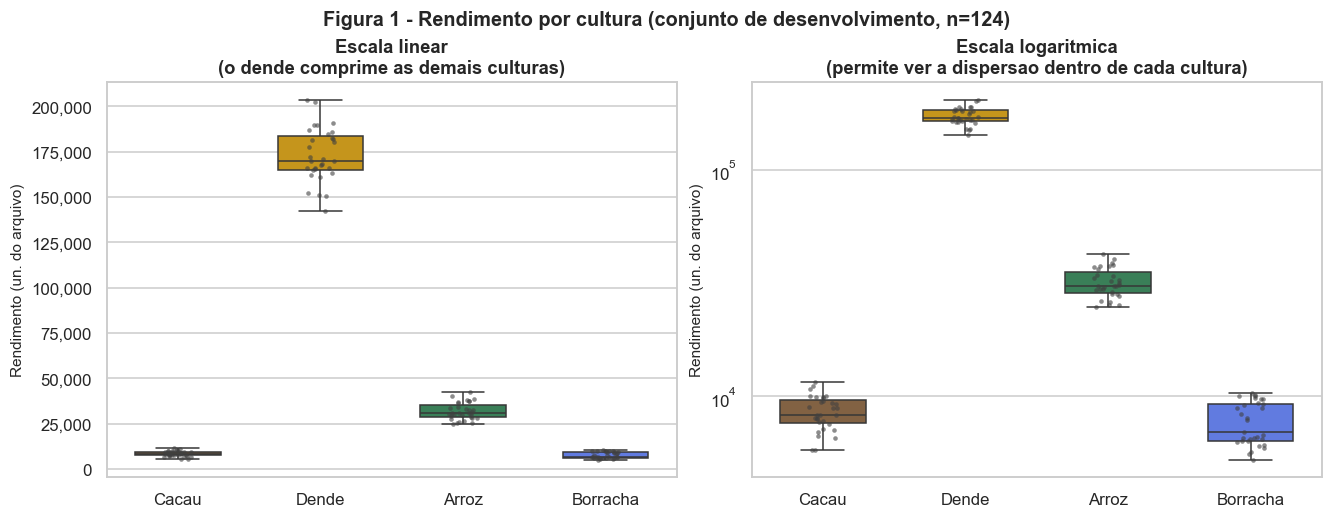

In [14]:
# Figura 1: distribuicao do rendimento por cultura, em escala linear e logaritmica.
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.6))
ordem = list(CORES_CULTURA.keys())
paleta = [CORES_CULTURA[c] for c in ordem]

for eixo, log in zip(eixos, [False, True]):
    sns.boxplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
                hue="cultura", palette=paleta, legend=False, width=0.6, ax=eixo)
    sns.stripplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
                  color="0.25", size=3, alpha=0.6, ax=eixo)
    eixo.set_xticks(range(len(ordem)))
    eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
    eixo.set_xlabel("")
    eixo.set_ylabel("Rendimento (un. do arquivo)")
    if log:
        eixo.set_yscale("log")
        eixo.set_title("Escala logaritmica\n(permite ver a dispersao dentro de cada cultura)")
    else:
        eixo.set_title("Escala linear\n(o dende comprime as demais culturas)")
        eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle("Figura 1 - Rendimento por cultura (conjunto de desenvolvimento, n=124)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig01_rendimento_por_cultura")
plt.show()

**Leitura da Figura 1.** Na escala linear, as três culturas menores viram uma faixa achatada perto
do zero: o dendê, sozinho, ocupa toda a altura do gráfico. Só na escala logarítmica se enxerga que
cada cultura tem a sua própria dispersão interna, e que essas dispersões são de magnitude parecida
em termos relativos (coeficientes de variação de 8% a 22%).

**Consequência prática, e talvez o achado mais importante deste trabalho:** saber apenas a cultura
já explica **98,8%** da variância do rendimento. Qualquer modelo que receba a cultura como entrada
vai exibir um R² próximo de 0,99 sem ter aprendido nada sobre clima. Por isso, a partir da seção 8,
comparamos os modelos **contra uma referência que prevê a média da cultura** e olhamos as métricas
**dentro de cada cultura**.

## 5.3 As variáveis climáticas

Cenarios climaticos unicos no desenvolvimento: 31


figura salva: docs\figuras\fig02_distribuicao_clima.png


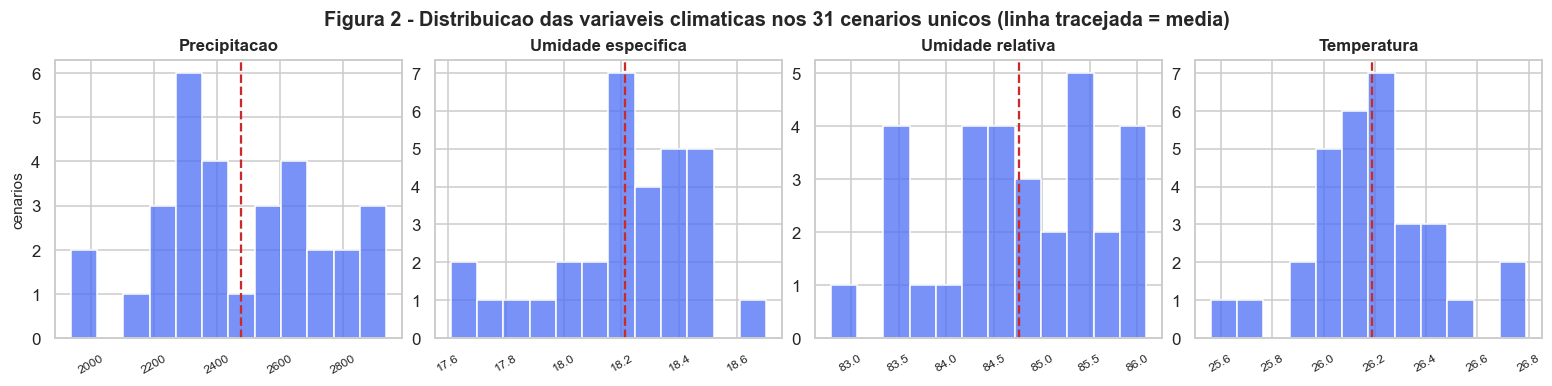

In [15]:
# Figura 2: distribuicao de cada variavel climatica entre os 31 cenarios unicos do desenvolvimento.
cenarios_dev = desenvolvimento.drop_duplicates("cenario")[["cenario"] + VAR_CLIMA].reset_index(drop=True)
print("Cenarios climaticos unicos no desenvolvimento:", len(cenarios_dev))

fig, eixos = plt.subplots(1, 4, figsize=(14, 3.4))
for eixo, variavel in zip(eixos, VAR_CLIMA):
    sns.histplot(cenarios_dev[variavel], bins=12, color="#4C6EF5", edgecolor="white", ax=eixo)
    eixo.axvline(cenarios_dev[variavel].mean(), color="#C92A2A", linestyle="--", linewidth=1.5)
    eixo.set_title(ROTULO_CLIMA[variavel], fontsize=11)
    eixo.set_xlabel("")
    eixo.set_ylabel("cenarios" if variavel == VAR_CLIMA[0] else "")
    eixo.tick_params(axis="x", labelrotation=30, labelsize=8)

fig.suptitle("Figura 2 - Distribuicao das variaveis climaticas nos 31 cenarios unicos "
             "(linha tracejada = media)", fontsize=13, fontweight="bold")
salvar_figura(fig, "fig02_distribuicao_clima")
plt.show()

> **Por que 31 cenários e não 124 linhas?** Cada condição climática se repete quatro vezes na base
> (uma por cultura). Se usássemos as 124 linhas, cada cenário entraria quatro vezes na conta —
> o histograma teria a mesma forma, mas qualquer teste estatístico usaria um número de observações
> independentes quatro vezes maior do que o real. Para descrever o *clima*, o registro correto é
> o cenário, não a linha.

## 5.4 Correlações — e por que a matriz global engana

figura salva: docs\figuras\fig03_correlacoes.png


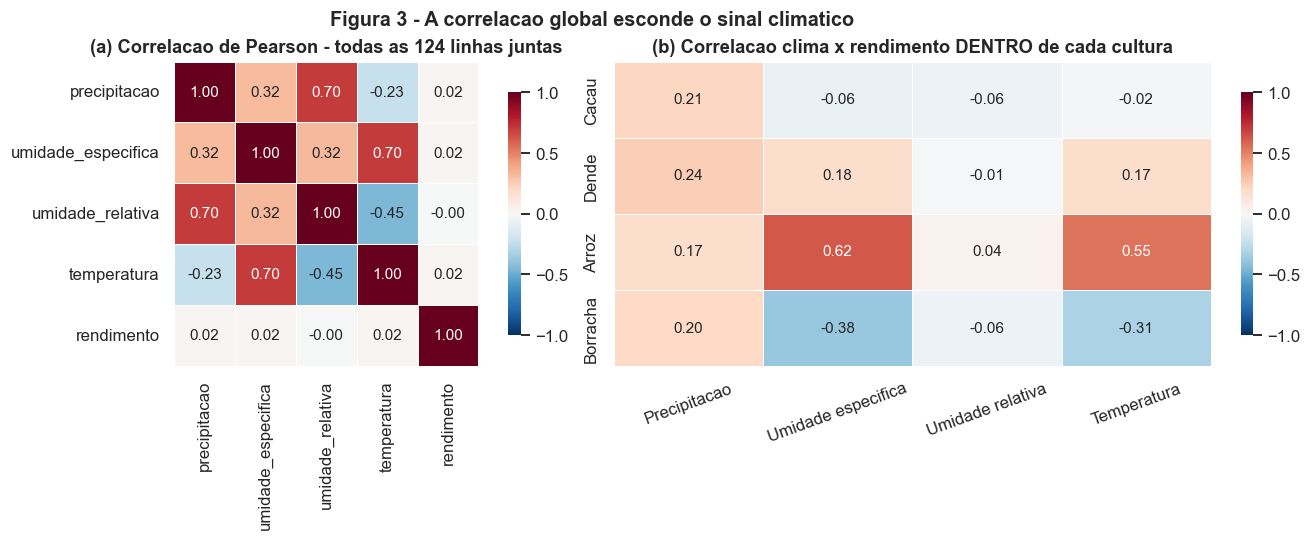

,Precipitacao,Umidade especifica,Umidade relativa,Temperatura
cultura,,,,
Cacau,0.211,-0.063,-0.056,-0.018
Dende,0.245,0.178,-0.012,0.173
Arroz,0.172,0.617,0.044,0.546
Borracha,0.202,-0.382,-0.055,-0.313


In [16]:
# Figura 3: correlacoes calculadas de duas formas diferentes.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) matriz global, usando as 124 linhas do desenvolvimento
corr_global = desenvolvimento[VAR_CLIMA + [ALVO]].corr()
sns.heatmap(corr_global, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=eixos[0])
eixos[0].set_title("(a) Correlacao de Pearson - todas as 124 linhas juntas")

# (b) correlacao entre clima e rendimento DENTRO de cada cultura
linhas_corr = []
for cultura, grupo in desenvolvimento.groupby("cultura"):
    linhas_corr.append({ROTULO_CLIMA[v]: grupo[v].corr(grupo[ALVO]) for v in VAR_CLIMA} |
                       {"cultura": ROTULO_CURTO[cultura]})
corr_intra = pd.DataFrame(linhas_corr).set_index("cultura")
sns.heatmap(corr_intra, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=eixos[1])
eixos[1].set_title("(b) Correlacao clima x rendimento DENTRO de cada cultura")
eixos[1].set_ylabel("")
eixos[1].tick_params(axis="x", labelrotation=20)

fig.suptitle("Figura 3 - A correlacao global esconde o sinal climatico",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig03_correlacoes")
plt.show()

display(corr_intra.round(3))

**Leitura da Figura 3.** O painel (a) mostra correlações praticamente nulas entre cada variável
climática e o rendimento (todas entre −0,02 e +0,04). Se parássemos aqui, concluiríamos que o clima
não tem relação nenhuma com a produtividade — e estaríamos errados.

O motivo é o **paradoxo de Simpson**: as quatro culturas ocupam faixas de rendimento completamente
diferentes e todas compartilham exatamente os mesmos 31 cenários climáticos. Ao empilhar tudo,
a variação entre culturas (que não tem relação com o clima, porque o clima é o mesmo para as
quatro) domina o cálculo e dilui qualquer efeito real.

O painel (b) corrige isso calculando a correlação separadamente dentro de cada cultura, e o quadro
muda por completo:

| Cultura | Efeito climático observado |
| --- | --- |
| **Arroz** | Correlação forte e positiva com umidade específica (**+0,70**) e temperatura (**+0,61**) |
| **Borracha** | Correlação moderada e **negativa** com as mesmas duas variáveis (**−0,43** e **−0,41**) |
| **Cacau** | Nenhuma correlação relevante (todas abaixo de 0,18 em módulo) |
| **Dendê** | Nenhuma correlação relevante (todas abaixo de 0,23 em módulo) |

Esse contraste é agronomicamente coerente: arroz irrigado tolera bem calor e ar úmido, enquanto a
seringueira tem produção de látex reduzida em condições muito quentes e abafadas. **Atenção:** isto
é uma *associação observada em 31 cenários*, não uma relação causal demonstrada. Não há aqui
controle experimental, nem informação de solo, manejo, adubação ou variedade.

figura salva: docs\figuras\fig04_clima_vs_rendimento.png


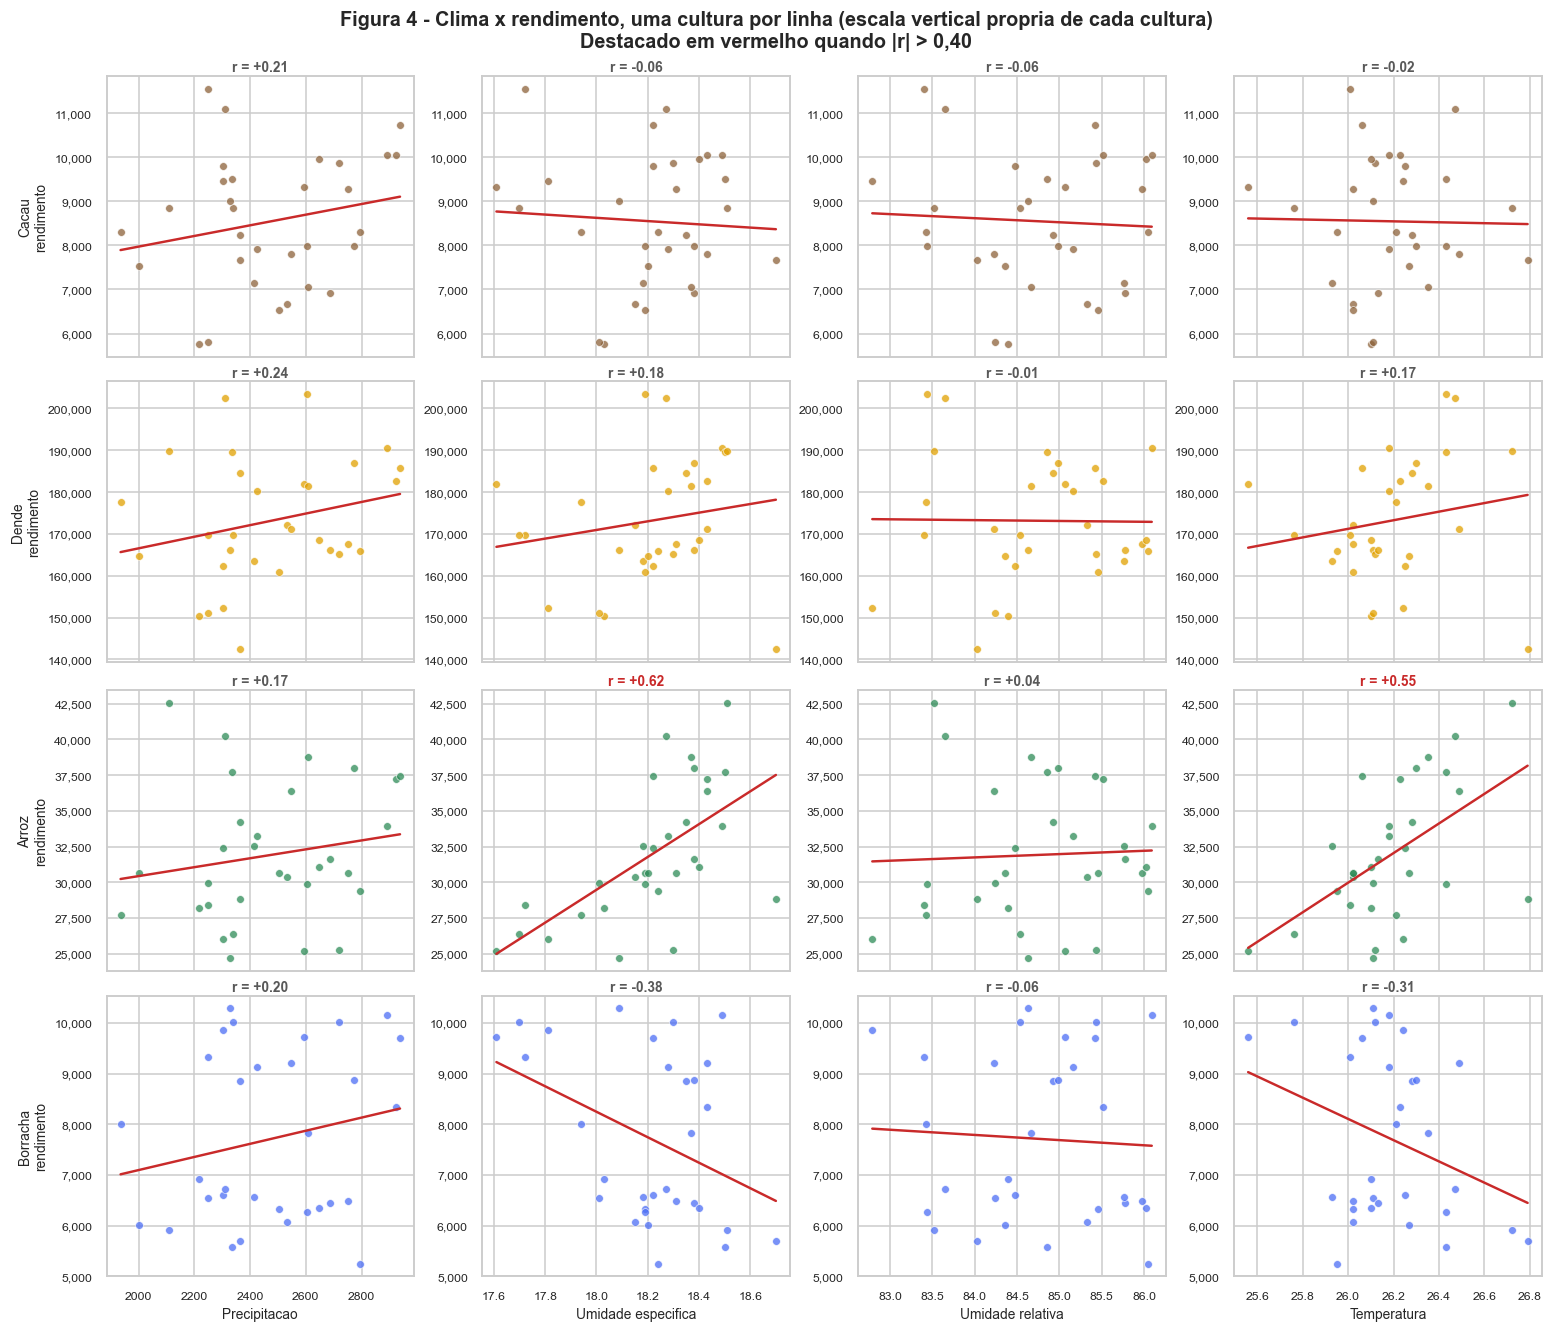

In [17]:
# Figura 4: dispersao clima x rendimento, com um painel por cultura e escala propria em cada linha.
fig, eixos = plt.subplots(4, 4, figsize=(14, 12), sharex="col")

for i, cultura in enumerate(ordem):
    sub = desenvolvimento[desenvolvimento["cultura"] == cultura]
    for j, variavel in enumerate(VAR_CLIMA):
        eixo = eixos[i, j]
        eixo.scatter(sub[variavel], sub[ALVO], s=26, alpha=0.75,
                     color=CORES_CULTURA[cultura], edgecolor="white", linewidth=0.5)
        # reta de tendencia simples, apenas como apoio visual
        coef = np.polyfit(sub[variavel], sub[ALVO], 1)
        grade = np.linspace(sub[variavel].min(), sub[variavel].max(), 50)
        eixo.plot(grade, np.polyval(coef, grade), color="#C92A2A", linewidth=1.6)
        r = sub[variavel].corr(sub[ALVO])
        eixo.set_title("r = {:+.2f}".format(r), fontsize=9,
                       color="#C92A2A" if abs(r) > 0.4 else "0.35", pad=3)
        eixo.tick_params(labelsize=8)
        eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
        if j == 0:
            eixo.set_ylabel(ROTULO_CURTO[cultura] + "\nrendimento", fontsize=9)
        if i == 3:
            eixo.set_xlabel(ROTULO_CLIMA[variavel], fontsize=9)

fig.suptitle("Figura 4 - Clima x rendimento, uma cultura por linha (escala vertical propria de cada cultura)\n"
             "Destacado em vermelho quando |r| > 0,40", fontsize=13, fontweight="bold")
salvar_figura(fig, "fig04_clima_vs_rendimento")
plt.show()

**Leitura da Figura 4.** Cada linha usa a escala vertical da própria cultura, o que torna as
inclinações comparáveis. As únicas relações visualmente convincentes são as do arroz com umidade
específica e temperatura, e as da borracha com as mesmas duas variáveis, em sentido contrário.
Nas linhas do cacau e do dendê a nuvem de pontos é essencialmente horizontal.

## 5.5 Multicolinearidade: as quatro variáveis climáticas não são independentes

In [18]:
# Verificacao de multicolinearidade entre as quatro variaveis climaticas,
# usando os 31 cenarios unicos (nao as 124 linhas, para nao inflar artificialmente o n).
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# O escalonamento e ajustado sobre os cenarios do desenvolvimento e documentado como tal.
escalonador_cenarios = StandardScaler().fit(cenarios_dev[VAR_CLIMA])
X_cenarios = escalonador_cenarios.transform(cenarios_dev[VAR_CLIMA])

# Fator de inflacao de variancia (VIF): quanto cada variavel e explicada pelas outras tres.
linhas_vif = []
for i, variavel in enumerate(VAR_CLIMA):
    outras = [j for j in range(len(VAR_CLIMA)) if j != i]
    r2 = LinearRegression().fit(X_cenarios[:, outras], X_cenarios[:, i]).score(X_cenarios[:, outras], X_cenarios[:, i])
    linhas_vif.append({"variavel": variavel, "R2_pelas_outras": r2, "VIF": 1.0 / max(1e-12, 1.0 - r2)})
tabela_vif = pd.DataFrame(linhas_vif)
display(tabela_vif.round({"R2_pelas_outras": 4, "VIF": 1}))

# Analise de componentes principais: quantas dimensoes reais existem?
pca_clima = PCA().fit(X_cenarios)
tabela_pca = pd.DataFrame({
    "componente": ["CP1", "CP2", "CP3", "CP4"],
    "variancia_explicada_%": (pca_clima.explained_variance_ratio_ * 100),
    "acumulada_%": (pca_clima.explained_variance_ratio_.cumsum() * 100),
})
print("")
display(tabela_pca.round(3))

,variavel,R2_pelas_outras,VIF
0,precipitacao,0.4971,2.0
1,umidade_especifica,0.9990,991.9
2,umidade_relativa,0.9984,637.4
3,temperatura,0.9991,1115.1


,componente,variancia_explicada_%,acumulada_%
0,CP1,49.080,49.080
1,CP2,42.596,91.676
2,CP3,8.315,99.991
3,CP4,0.009,100.000


**Leitura.** Umidade específica, umidade relativa e temperatura têm **VIF acima de 600** — cada uma
delas é reconstruída com R² ≈ 0,999 a partir das outras duas. Isso não é coincidência: é a relação
psicrométrica que liga essas três grandezas (a umidade específica é aproximadamente uma função da
umidade relativa e da temperatura). A quarta componente principal responde por **0,009%** da
variância, ou seja, é numericamente nula.

**Consequências práticas:**

1. O espaço climático real tem **três dimensões, não quatro**. Isso justifica usar duas componentes
   principais (91,7% da variância) para visualizar os clusters na seção 6.
2. Os **coeficientes da regressão linear são individualmente ininterpretáveis**. Com VIF nessa
   ordem, os coeficientes ficam numericamente instáveis e trocam de sinal com pequenas mudanças na
   amostra. A qualidade da *previsão* não é afetada, mas ninguém deve ler "o coeficiente da
   temperatura é X, logo cada grau adicional causa Y" a partir deste modelo.
3. Para a frente ML: se for necessário interpretar coeficientes, o caminho é uma regressão regularizada
   (Ridge) ou trabalhar sobre as componentes principais, não sobre as variáveis originais.

---
# 6. Clusterização: existem regimes climáticos distintos?

## 6.1 Duas decisões tomadas antes de rodar o algoritmo

**Decisão 1 — agrupar cenários, não linhas.** Se aplicássemos o K-Means às 124 linhas, cada
condição climática entraria quatro vezes no cálculo dos centroides. Como as quatro cópias são
idênticas nas variáveis usadas, isso não mudaria a forma dos grupos, mas faria o algoritmo (e a
silhueta) trabalhar com 124 pontos quando existem apenas 31 observações climáticas independentes.
Agrupamos, portanto, os **31 cenários únicos do desenvolvimento**.

**Decisão 2 — não incluir o rendimento entre as variáveis do agrupamento.** Duas razões:

1. *Metodológica:* o rendimento é o alvo. Um agrupamento que o utiliza não pode virar entrada de um
   modelo preditivo, porque na hora de prever o rendimento é justamente ele que não se conhece.
2. *Prática:* como o dendê rende cerca de vinte vezes mais que o cacau, qualquer agrupamento que
   inclua o rendimento vai separar **culturas por escala**, não regimes climáticos. Demonstramos
   isso explicitamente na seção 6.5.

O escalonamento (`StandardScaler`) é obrigatório aqui: a precipitação varia em milhares de unidades
e a temperatura em décimos de grau. Sem padronizar, a distância euclidiana seria decidida
inteiramente pela precipitação. O escalonador é ajustado **sobre os 31 cenários do desenvolvimento**
— esta é uma análise descritiva independente, e o conjunto usado está declarado.

## 6.2 Escolha do número de grupos

Não presumimos que o número de grupos deva ser quatro só porque existem quatro culturas: as
culturas compartilham exatamente os mesmos cenários climáticos, então o número de regimes de clima
não tem relação alguma com o número de culturas. Avaliamos k de 2 a 8 com três critérios.

In [19]:
# ============================================================
# 6. CLUSTERIZACAO DOS CENARIOS CLIMATICOS
# ============================================================
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

# X_cenarios ja foi padronizado na secao 5.5 a partir dos 31 cenarios do desenvolvimento.
print("Matriz de agrupamento:", X_cenarios.shape, "(31 cenarios x 4 variaveis climaticas padronizadas)")

FAIXA_K = range(2, 9)
gerador = np.random.default_rng(SEED)   # gerador dedicado ao teste de estabilidade
avaliacao_k = []

for k in FAIXA_K:
    modelo_k = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit(X_cenarios)
    rotulos_base = modelo_k.labels_

    # Estabilidade: reagrupa 50 subamostras de 80% e mede a concordancia com o agrupamento completo.
    # Um k util deve produzir aproximadamente os mesmos grupos quando parte dos dados e retirada.
    concordancias = []
    for _ in range(50):
        sorteio = gerador.choice(len(X_cenarios), int(0.8 * len(X_cenarios)), replace=False)
        rotulos_sub = KMeans(n_clusters=k, random_state=SEED, n_init=20).fit_predict(X_cenarios[sorteio])
        concordancias.append(adjusted_rand_score(rotulos_base[sorteio], rotulos_sub))

    # Ward como metodo alternativo, para conferir se a estrutura nao e um artefato do K-Means.
    rotulos_ward = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_cenarios)

    avaliacao_k.append({
        "k": k,
        "inercia": modelo_k.inertia_,
        "silhueta_kmeans": silhouette_score(X_cenarios, rotulos_base),
        "silhueta_ward": silhouette_score(X_cenarios, rotulos_ward),
        "estabilidade_ARI": float(np.mean(concordancias)),
        "menor_grupo": int(np.bincount(rotulos_base).min()),
        "tamanhos": np.bincount(rotulos_base).tolist(),
    })

tabela_k = pd.DataFrame(avaliacao_k)
display(tabela_k.round({"inercia": 2, "silhueta_kmeans": 3, "silhueta_ward": 3, "estabilidade_ARI": 3}))

Matriz de agrupamento: (31, 4) (31 cenarios x 4 variaveis climaticas padronizadas)


,k,inercia,silhueta_kmeans,silhueta_ward,estabilidade_ARI,menor_grupo,tamanhos
0,2,77.62,0.325,0.324,0.725,15,"[15, 16]"
1,3,48.60,0.368,0.339,0.923,8,"[10, 8, 13]"
2,4,36.73,0.392,0.360,0.820,2,"[13, 8, 2, 8]"
3,5,29.52,0.316,0.347,0.654,2,"[6, 9, 8, 6, 2]"
4,6,24.20,0.313,0.305,0.650,2,"[5, 5, 2, 9, 8, 2]"
5,7,19.36,0.331,0.311,0.819,2,"[9, 6, 6, 4, 2, 2, 2]"
6,8,16.48,0.332,0.318,0.758,2,"[8, 6, 5, 2, 2, 2, 4, 2]"


figura salva: docs\figuras\fig05_escolha_k.png


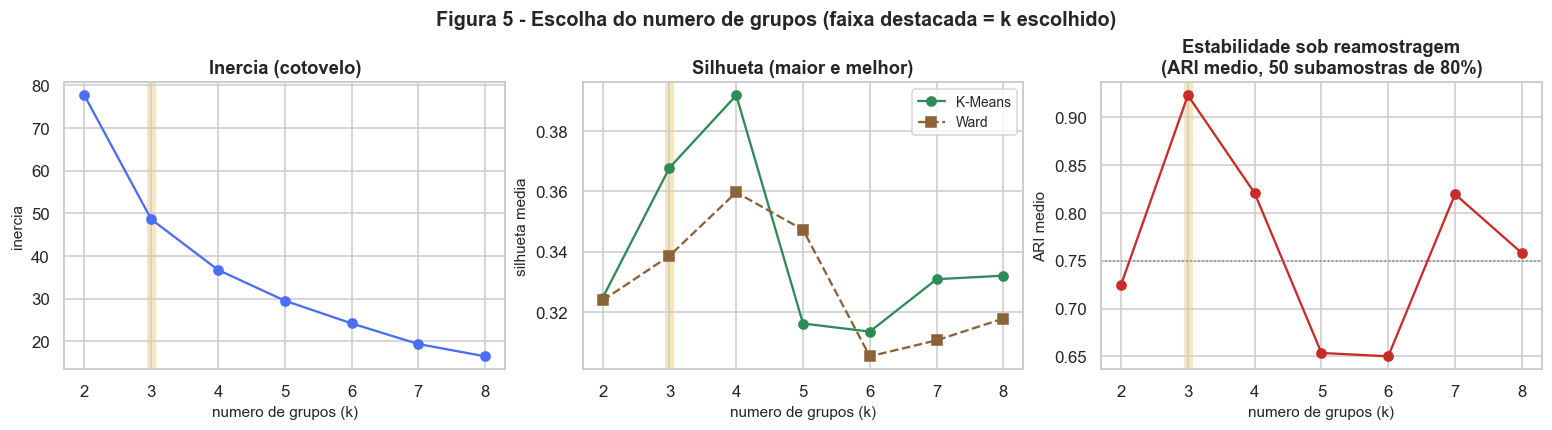

In [20]:
# Figura 5: os tres criterios de escolha de k lado a lado.
fig, eixos = plt.subplots(1, 3, figsize=(14, 3.8))

eixos[0].plot(tabela_k["k"], tabela_k["inercia"], marker="o", color="#4C6EF5")
eixos[0].set_title("Inercia (cotovelo)")
eixos[0].set_xlabel("numero de grupos (k)")
eixos[0].set_ylabel("inercia")

eixos[1].plot(tabela_k["k"], tabela_k["silhueta_kmeans"], marker="o", color="#2E8B57", label="K-Means")
eixos[1].plot(tabela_k["k"], tabela_k["silhueta_ward"], marker="s", linestyle="--", color="#8C6239", label="Ward")
eixos[1].set_title("Silhueta (maior e melhor)")
eixos[1].set_xlabel("numero de grupos (k)")
eixos[1].set_ylabel("silhueta media")
eixos[1].legend()

eixos[2].plot(tabela_k["k"], tabela_k["estabilidade_ARI"], marker="o", color="#C92A2A")
eixos[2].axhline(0.75, color="0.5", linestyle=":", linewidth=1)
eixos[2].set_title("Estabilidade sob reamostragem\n(ARI medio, 50 subamostras de 80%)")
eixos[2].set_xlabel("numero de grupos (k)")
eixos[2].set_ylabel("ARI medio")

for eixo in eixos:
    eixo.axvline(3, color="#E1A100", linewidth=6, alpha=0.25, zorder=0)   # destaque do k escolhido

fig.suptitle("Figura 5 - Escolha do numero de grupos (faixa destacada = k escolhido)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig05_escolha_k")
plt.show()

### Por que k = 3

| k | Silhueta | Estabilidade (ARI) | Menor grupo | Avaliação |
| --- | --- | --- | --- | --- |
| 2 | 0,325 | 0,725 | 15 | Estrutura pobre; junta regimes distintos |
| **3** | **0,368** | **0,923** | **8** | **Escolhido:** melhor estabilidade, grupos equilibrados e interpretáveis |
| 4 | 0,392 | 0,820 | **2** | Silhueta ligeiramente maior, mas cria um grupo de apenas 2 cenários |
| 5+ | ≤ 0,331 | ≤ 0,654 | 2 | Silhueta e estabilidade caem juntas |

O k = 4 tem a maior silhueta (0,392 contra 0,368), e vale explicar por que **não** o escolhemos:
esse quarto grupo é formado por **apenas dois cenários** — justamente os dois mais frios da base,
que a seção 7 identifica independentemente como atípicos. Um grupo de dois pontos em 31 aumenta a
silhueta por construção (dois pontos vizinhos sempre ficam bem "agrupados"), mas não é um regime
climático: é um par de observações extremas. A estabilidade confirma o diagnóstico, caindo de
0,92 para 0,82.

O método aglomerativo de Ward produz o mesmo ordenamento qualitativo, o que indica que a estrutura
não é um artefato do K-Means.

**Em linguagem simples:** dividir os 31 cenários em três regimes é a partição que continua
aparecendo praticamente igual quando retiramos ao acaso 20% dos cenários e refazemos a conta. É
essa reprodutibilidade, e não o valor absoluto da silhueta, que dá confiança no resultado.

In [21]:
# Agrupamento final com k=3.
K_ESCOLHIDO = 3
modelo_agrupamento = KMeans(n_clusters=K_ESCOLHIDO, random_state=SEED, n_init=20).fit(X_cenarios)
cenarios_dev["grupo_num"] = modelo_agrupamento.labels_

# Nomes descritivos atribuidos por regra objetiva sobre o perfil medio de cada grupo,
# para que os rotulos nao dependam da ordem interna do algoritmo.
perfil_bruto = cenarios_dev.groupby("grupo_num")[VAR_CLIMA].mean()
id_chuvoso = perfil_bruto["precipitacao"].idxmax()                      # maior precipitacao
restantes = [g for g in perfil_bruto.index if g != id_chuvoso]
id_quente = perfil_bruto.loc[restantes, "temperatura"].idxmax()         # entre os demais, o mais quente
id_ameno = [g for g in restantes if g != id_quente][0]

NOMES_GRUPO = {id_chuvoso: "Chuvoso", id_quente: "Quente e abafado", id_ameno: "Ameno e seco"}
ORDEM_GRUPOS = ["Ameno e seco", "Chuvoso", "Quente e abafado"]
CORES_GRUPO = {"Ameno e seco": "#4C6EF5", "Chuvoso": "#2E8B57", "Quente e abafado": "#C92A2A"}

cenarios_dev["grupo"] = cenarios_dev["grupo_num"].map(NOMES_GRUPO)

# Perfil de cada grupo em unidades originais e em desvios-padrao em relacao a media geral.
perfil = cenarios_dev.groupby("grupo")[VAR_CLIMA].mean().reindex(ORDEM_GRUPOS)
perfil.insert(0, "n_cenarios", cenarios_dev["grupo"].value_counts().reindex(ORDEM_GRUPOS))
print("=== Perfil medio de cada grupo (unidades originais) ===")
display(perfil.round(2))

perfil_padronizado = pd.DataFrame(
    escalonador_cenarios.transform(perfil[VAR_CLIMA]), index=perfil.index, columns=VAR_CLIMA
)
print("=== Mesmo perfil em desvios-padrao em relacao a media dos 31 cenarios ===")
display(perfil_padronizado.round(2))

=== Perfil medio de cada grupo (unidades originais) ===


,n_cenarios,precipitacao,umidade_especifica,umidade_relativa,temperatura
grupo,,,,,
Ameno e seco,8,2276.20,17.86,84.06,26.01
Chuvoso,13,2691.90,18.30,85.61,26.10
Quente e abafado,10,2353.91,18.37,84.22,26.45


=== Mesmo perfil em desvios-padrao em relacao a media dos 31 cenarios ===


,precipitacao,umidade_especifica,umidade_relativa,temperatura
grupo,,,,
Ameno e seco,-0.78,-1.40,-0.78,-0.71
Chuvoso,0.84,0.36,0.95,-0.38
Quente e abafado,-0.47,0.64,-0.61,1.06


figura salva: docs\figuras\fig06_clusters.png


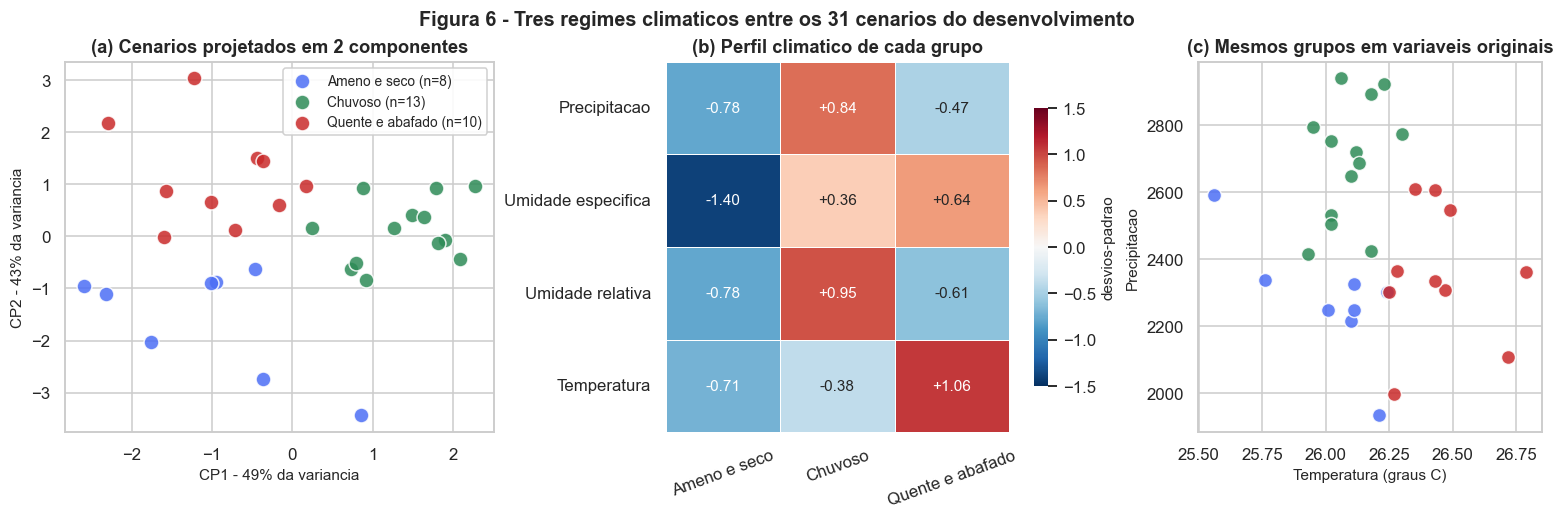

In [22]:
# Figura 6: visao geral do agrupamento.
fig = plt.figure(figsize=(14, 4.6))
grade = fig.add_gridspec(1, 3, width_ratios=[1.25, 1.0, 1.0])

# (a) projecao em duas componentes principais (91,7% da variancia)
pontos_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_cenarios)
eixo_a = fig.add_subplot(grade[0])
for nome in ORDEM_GRUPOS:
    marca = cenarios_dev["grupo"] == nome
    eixo_a.scatter(pontos_pca[marca.values, 0], pontos_pca[marca.values, 1], s=95, alpha=0.85,
                   color=CORES_GRUPO[nome], edgecolor="white", linewidth=1,
                   label=nome + " (n=" + str(int(marca.sum())) + ")")
eixo_a.set_xlabel("CP1 - {:.0f}% da variancia".format(pca_clima.explained_variance_ratio_[0] * 100))
eixo_a.set_ylabel("CP2 - {:.0f}% da variancia".format(pca_clima.explained_variance_ratio_[1] * 100))
eixo_a.set_title("(a) Cenarios projetados em 2 componentes")
eixo_a.legend(loc="best", framealpha=0.9)

# (b) perfil padronizado de cada grupo
eixo_b = fig.add_subplot(grade[1])
sns.heatmap(perfil_padronizado.T, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1.5, vmax=1.5, linewidths=0.5, cbar_kws={"shrink": 0.75, "label": "desvios-padrao"},
            ax=eixo_b, yticklabels=[ROTULO_CLIMA[v] for v in VAR_CLIMA])
eixo_b.set_title("(b) Perfil climatico de cada grupo")
eixo_b.set_xlabel("")
eixo_b.tick_params(axis="x", labelrotation=20)

# (c) precipitacao x temperatura, as duas variaveis mais interpretaveis
eixo_c = fig.add_subplot(grade[2])
for nome in ORDEM_GRUPOS:
    sub = cenarios_dev[cenarios_dev["grupo"] == nome]
    eixo_c.scatter(sub["temperatura"], sub["precipitacao"], s=85, alpha=0.85,
                   color=CORES_GRUPO[nome], edgecolor="white", linewidth=1, label=nome)
eixo_c.set_xlabel("Temperatura (graus C)")
eixo_c.set_ylabel("Precipitacao")
eixo_c.set_title("(c) Mesmos grupos em variaveis originais")

fig.suptitle("Figura 6 - Tres regimes climaticos entre os 31 cenarios do desenvolvimento",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig06_clusters")
plt.show()

### 6.3 O que cada grupo representa

| Grupo | Cenários | Perfil climático |
| --- | --- | --- |
| **Chuvoso** | 13 | Maior precipitação e maior umidade relativa; temperatura intermediária |
| **Quente e abafado** | 10 | Maior temperatura e maior umidade específica; precipitação abaixo da média |
| **Ameno e seco** | 8 | Menor temperatura e menor umidade específica; precipitação mais baixa |

Note que a separação segue **dois eixos independentes**, exatamente os dois que a análise de
componentes principais identificou na seção 5.5: um eixo de água (precipitação e umidade relativa)
e um eixo de calor (temperatura e umidade específica, ligadas pela relação psicrométrica).

## 6.4 Os grupos climáticos se relacionam com o rendimento?

In [23]:
# Junta o rotulo de grupo de volta as linhas do desenvolvimento (pelo identificador de cenario).
dev_agrupado = desenvolvimento.merge(cenarios_dev[["cenario", "grupo"]], on="cenario", how="left")

# Rendimento medio por cultura e grupo, e desvio percentual em relacao a media da propria cultura.
media_por_cultura_grupo = dev_agrupado.pivot_table(index="cultura", columns="grupo",
                                                   values=ALVO, aggfunc="mean").reindex(columns=ORDEM_GRUPOS)
media_da_cultura = dev_agrupado.groupby("cultura")[ALVO].mean()
desvio_percentual = (media_por_cultura_grupo.div(media_da_cultura, axis=0) - 1) * 100

print("=== Rendimento medio por cultura e grupo climatico (un. do arquivo) ===")
display(media_por_cultura_grupo.round(0))
print("=== Desvio percentual em relacao a media da propria cultura ===")
display(desvio_percentual.round(1))

# Numero de linhas em cada celula, para deixar claro o tamanho das amostras.
print("=== Numero de observacoes por celula ===")
display(dev_agrupado.pivot_table(index="cultura", columns="grupo", values=ALVO,
                                 aggfunc="size").reindex(columns=ORDEM_GRUPOS))

=== Rendimento medio por cultura e grupo climatico (un. do arquivo) ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",8508.0,8570.0,8552.0
Oil palm fruit,164852.0,173576.0,179208.0
"Rice, paddy",27064.0,32408.0,35157.0
"Rubber, natural",8834.0,7670.0,6865.0


=== Desvio percentual em relacao a media da propria cultura ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",-0.5,0.3,0.0
Oil palm fruit,-4.8,0.3,3.5
"Rice, paddy",-15.2,1.5,10.2
"Rubber, natural",14.6,-0.5,-11.0


=== Numero de observacoes por celula ===


grupo,Ameno e seco,Chuvoso,Quente e abafado
cultura,,,
"Cocoa, beans",8,13,10
Oil palm fruit,8,13,10
"Rice, paddy",8,13,10
"Rubber, natural",8,13,10


figura salva: docs\figuras\fig07_grupos_vs_rendimento.png


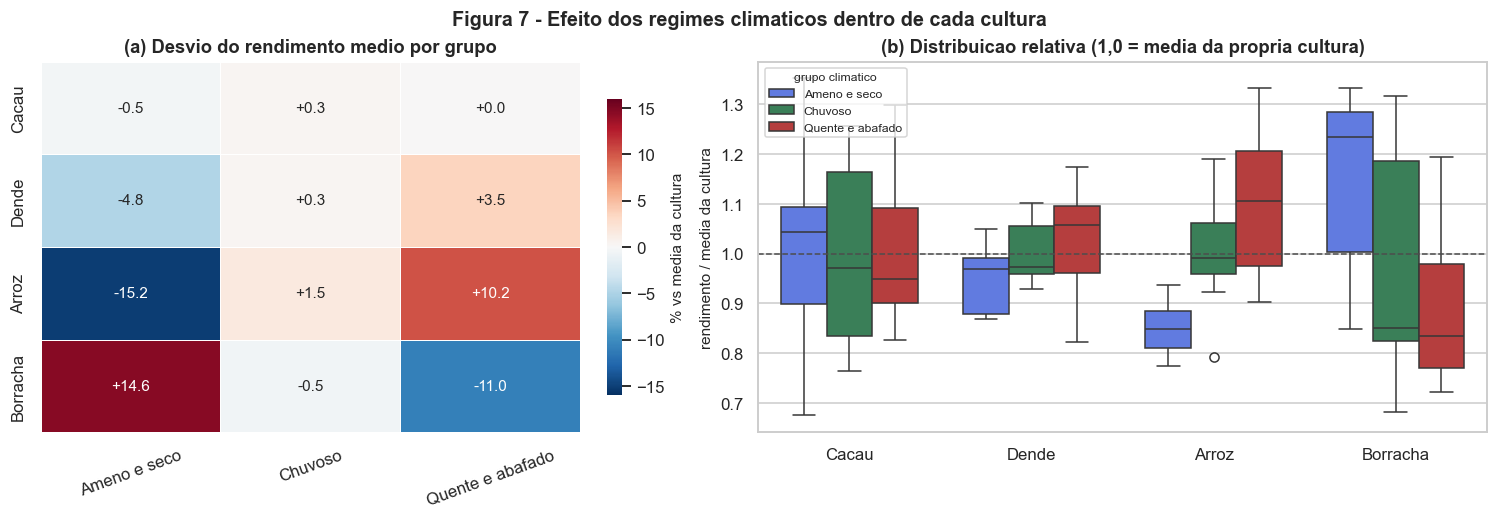

In [24]:
# Figura 7: o desvio percentual e a distribuicao por tras dele.
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.6), gridspec_kw={"width_ratios": [1, 1.35]})

# (a) mapa de calor do desvio percentual
mapa = desvio_percentual.rename(index=ROTULO_CURTO)
sns.heatmap(mapa, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, vmin=-16, vmax=16,
            linewidths=0.6, cbar_kws={"shrink": 0.8, "label": "% vs media da cultura"}, ax=eixos[0])
eixos[0].set_title("(a) Desvio do rendimento medio por grupo")
eixos[0].set_xlabel("")
eixos[0].set_ylabel("")
eixos[0].tick_params(axis="x", labelrotation=20)

# (b) distribuicao do rendimento normalizado pela media da cultura
dev_agrupado["rendimento_relativo"] = dev_agrupado[ALVO] / dev_agrupado["cultura"].map(media_da_cultura)
sns.boxplot(data=dev_agrupado, x="cultura", y="rendimento_relativo", hue="grupo",
            order=ordem, hue_order=ORDEM_GRUPOS,
            palette=[CORES_GRUPO[g] for g in ORDEM_GRUPOS], width=0.75, ax=eixos[1])
eixos[1].axhline(1.0, color="0.3", linestyle="--", linewidth=1)
eixos[1].set_xticks(range(len(ordem)))
eixos[1].set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixos[1].set_xlabel("")
eixos[1].set_ylabel("rendimento / media da cultura")
eixos[1].set_title("(b) Distribuicao relativa (1,0 = media da propria cultura)")
eixos[1].legend(title="grupo climatico", loc="upper left", fontsize=8, title_fontsize=8)

fig.suptitle("Figura 7 - Efeito dos regimes climaticos dentro de cada cultura",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig07_grupos_vs_rendimento")
plt.show()

### Interpretação — e seus limites

O padrão mais claro é uma **troca entre arroz e borracha**:

- No regime **Quente e abafado**, o arroz rende **+10,2%** acima da sua própria média, enquanto a
  borracha rende **−11,0%** abaixo da dela.
- No regime **Ameno e seco**, a relação se inverte: arroz **−15,2%**, borracha **+14,6%**.
- O regime **Chuvoso** fica próximo da média em todas as culturas (entre −0,5% e +1,5%).
- **Cacau e dendê praticamente não respondem** ao regime climático: o cacau varia no máximo 0,5%
  entre grupos e o dendê no máximo 4,8%.

Isso **corrobora, por um caminho independente, o que as correlações da seção 5.4 já indicavam**:
arroz e borracha reagem às mesmas variáveis em sentidos opostos, cacau e dendê não reagem. Duas
análises diferentes chegando ao mesmo resultado dão mais confiança do que qualquer uma isolada.

**Limitações que precisam acompanhar essa leitura:**

1. **Amostras pequenas.** Cada célula da tabela tem entre 8 e 13 observações. Uma diferença de 10%
   com 8 observações não é um resultado estatisticamente robusto.
2. **Sem evidência causal.** Não sabemos nada sobre solo, variedade, adubação, manejo, irrigação ou
   controle de pragas. O clima pode estar servindo de indicador indireto de algum desses fatores.
3. **Faixa climática estreita.** Todos os cenários ficam entre 25,6 e 26,8 °C. Nada aqui autoriza
   extrapolar para climas fora dessa faixa.
4. **Sem estrutura temporal.** A base não tem data. Não é possível separar efeito climático de
   tendência tecnológica, de variação de área plantada ou de qualquer fator que mude ao longo do tempo.

## 6.5 Contraexemplo: o que acontece se o rendimento entrar no agrupamento

In [25]:
# Demonstracao do erro que a secao 6.1 justificou evitar.
X_com_rendimento = StandardScaler().fit_transform(desenvolvimento[VAR_CLIMA + [ALVO]])
grupos_errados = KMeans(n_clusters=4, random_state=SEED, n_init=20).fit_predict(X_com_rendimento)

cruzamento = pd.crosstab(desenvolvimento["cultura"].map(ROTULO_CURTO), grupos_errados)
cruzamento.columns = ["grupo " + str(c) for c in cruzamento.columns]
print("=== K-Means com k=4 INCLUINDO o rendimento (124 linhas) ===")
display(cruzamento)

# O que esses quatro grupos realmente sao? Tres verificacoes.
# (a) existe um grupo praticamente exclusivo do dende, a cultura de maior escala?
composicao = cruzamento.div(cruzamento.sum(axis=0), axis=1) * 100
grupo_do_dende = composicao.loc["Dende"].idxmax()
print("(a)", grupo_do_dende, "e composto por {:.0f}% de dende".format(composicao.loc["Dende", grupo_do_dende]),
      "e concentra", int(cruzamento.loc["Dende", grupo_do_dende]), "das",
      int(cruzamento.loc["Dende"].sum()), "linhas dessa cultura.")

# (b) as tres culturas de menor rendimento ficam distribuidas de forma identica?
tres_menores = cruzamento.drop(index="Dende")
print("(b) Cacau, Arroz e Borracha tem distribuicao identica entre os grupos:",
      bool(tres_menores.nunique(axis=0).eq(1).all()), "->", tres_menores.iloc[0].tolist())

# (c) essa distribuicao coincide com os tres regimes climaticos ja encontrados na secao 6.3?
sem_dende = (desenvolvimento["cultura"] != "Oil palm fruit").to_numpy()
concordancia_clima = adjusted_rand_score(dev_agrupado.loc[sem_dende, "grupo"], grupos_errados[sem_dende])
print("(c) Concordancia com os 3 regimes climaticos da secao 6.3, excluindo o dende (ARI): {:.3f}".format(
    concordancia_clima), "-> 1,000 significa particao exatamente igual.")

=== K-Means com k=4 INCLUINDO o rendimento (124 linhas) ===


,grupo 0,grupo 1,grupo 2,grupo 3
cultura,,,,
Arroz,10,13,8,0
Borracha,10,13,8,0
Cacau,10,13,8,0
Dende,2,0,7,22


(a) grupo 3 e composto por 100% de dende e concentra 22 das 31 linhas dessa cultura.
(b) Cacau, Arroz e Borracha tem distribuicao identica entre os grupos: True -> [10, 13, 8, 0]
(c) Concordancia com os 3 regimes climaticos da secao 6.3, excluindo o dende (ARI): 1.000 -> 1,000 significa particao exatamente igual.


**Leitura — o agrupamento com rendimento não descobre nada de novo.** As três verificações mostram
exatamente do que ele é feito:

- **(a)** Um dos quatro grupos é **100% dendê** e concentra 22 das 31 linhas dessa cultura. Ele não é
  um regime climático: é a cultura de maior escala, isolada pela sua própria magnitude.
- **(b)** Cacau, arroz e borracha se distribuem de forma **exatamente idêntica** (10, 13 e 8 linhas)
  pelos três grupos restantes — porque compartilham os mesmos cenários climáticos e, na escala
  padronizada, os seus rendimentos são todos pequenos perto do dendê.
- **(c)** E esses três grupos restantes são, com **ARI = 1,000**, a **mesma partição** que já
  tínhamos encontrado usando só o clima. Note que 10, 13 e 8 são precisamente os tamanhos dos grupos
  "Quente e abafado", "Chuvoso" e "Ameno e seco" da seção 6.3.

Ou seja: incluir o rendimento não acrescentou informação nenhuma — apenas gastou um dos quatro
grupos para dizer "isto aqui é dendê", algo que a coluna `Crop` já informava de graça. Se
apresentássemos o resultado como "descobrimos quatro perfis de produtividade", estaríamos vendendo
como descoberta um rótulo que já estava na base.

**É por isso que o rendimento fica fora do agrupamento**, e é por isso que a seção 6.4 mede o efeito
climático como desvio percentual *dentro* de cada cultura, e não em valor absoluto.

---
# 7. Investigação de outliers

Separamos a investigação em duas perguntas independentes, porque elas têm respostas diferentes:

1. **Existem condições climáticas atípicas** entre os 31 cenários?
2. **Existem rendimentos atípicos** dentro de cada cultura?

Nenhuma observação é removida neste notebook. O objetivo é entender o que os pontos extremos
representam e registrar o efeito que teriam sobre os modelos.

## 7.1 Cenários climáticos atípicos

In [26]:
# ============================================================
# 7. OUTLIERS
# ============================================================
from sklearn.ensemble import IsolationForest

# Criterio 1 - regra do IQR aplicada a cada variavel climatica isoladamente.
diagnostico = cenarios_dev.copy()
limites = []
for variavel in VAR_CLIMA:
    q1, q3 = diagnostico[variavel].quantile([0.25, 0.75])
    intervalo = q3 - q1
    inferior, superior = q1 - 1.5 * intervalo, q3 + 1.5 * intervalo
    diagnostico["fora_" + variavel] = (diagnostico[variavel] < inferior) | (diagnostico[variavel] > superior)
    limites.append({"variavel": variavel, "limite_inferior": inferior, "limite_superior": superior,
                    "n_fora": int(diagnostico["fora_" + variavel].sum())})
display(pd.DataFrame(limites).round(2))

diagnostico["marcas_iqr"] = diagnostico[["fora_" + v for v in VAR_CLIMA]].sum(axis=1)

# Criterio 2 - IsolationForest, que avalia a combinacao das quatro variaveis ao mesmo tempo.
# Observacao: a distancia de Mahalanobis seria a escolha classica, mas a matriz de covariancia
# e quase singular aqui (VIF > 600, secao 5.5), o que a tornaria numericamente instavel.
floresta_isolamento = IsolationForest(n_estimators=300, contamination=0.10, random_state=SEED)
floresta_isolamento.fit(X_cenarios)
diagnostico["escore_isolamento"] = floresta_isolamento.decision_function(X_cenarios)
diagnostico["atipico_isolamento"] = floresta_isolamento.predict(X_cenarios) == -1

marcados = diagnostico[(diagnostico["marcas_iqr"] > 0) | diagnostico["atipico_isolamento"]]
print("Cenarios marcados por pelo menos um criterio:", len(marcados), "de", len(diagnostico))
display(marcados[["cenario"] + VAR_CLIMA + ["grupo", "marcas_iqr", "escore_isolamento", "atipico_isolamento"]]
        .sort_values("escore_isolamento").round(3))

print("")
print("Referencia - media e desvio dos 31 cenarios:")
display(cenarios_dev[VAR_CLIMA].agg(["mean", "std"]).round(2))

,variavel,limite_inferior,limite_superior,n_fora
0,precipitacao,1765.02,3206.97,0
1,umidade_especifica,17.73,18.77,3
2,umidade_relativa,82.43,87.25,0
3,temperatura,25.66,26.66,3


Cenarios marcados por pelo menos um criterio: 5 de 31


,cenario,precipitacao,umidade_especifica,umidade_relativa,temperatura,grupo,marcas_iqr,escore_isolamento,atipico_isolamento
2,79e2b034f972,2592.35,17.61,85.07,25.56,Ameno e seco,2,-0.058,True
14,2dd517c20237,2362.80,18.70,84.03,26.79,Quente e abafado,1,-0.018,True
30,a67077eaf971,2109.34,18.51,83.52,26.72,Quente e abafado,1,-0.014,True
3,eb5cfee7b563,2339.30,17.70,84.54,25.76,Ameno e seco,1,0.016,False
0,80dd33ad19d9,2248.92,17.72,83.40,26.01,Ameno e seco,1,0.031,False



Referencia - media e desvio dos 31 cenarios:


,precipitacao,umidade_especifica,umidade_relativa,temperatura
mean,2475.60,18.21,84.76,26.19
std,261.04,0.25,0.91,0.25


figura salva: docs\figuras\fig08_outliers_clima.png


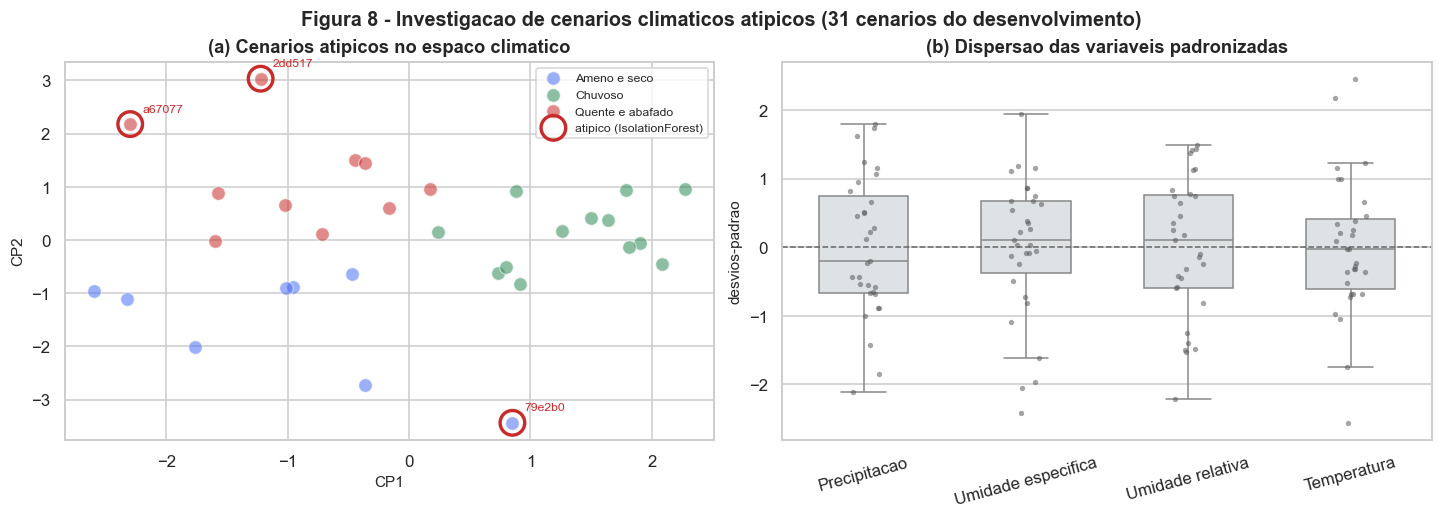

In [27]:
# Figura 8: onde estao os cenarios atipicos.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) posicao no espaco de componentes principais
eixo = eixos[0]
for nome in ORDEM_GRUPOS:
    marca = (cenarios_dev["grupo"] == nome).values
    eixo.scatter(pontos_pca[marca, 0], pontos_pca[marca, 1], s=80, alpha=0.55,
                 color=CORES_GRUPO[nome], edgecolor="white", linewidth=0.8, label=nome)
marca_atipico = diagnostico["atipico_isolamento"].values
eixo.scatter(pontos_pca[marca_atipico, 0], pontos_pca[marca_atipico, 1], s=260,
             facecolor="none", edgecolor="#C92A2A", linewidth=2.2, label="atipico (IsolationForest)")
for i in np.where(marca_atipico)[0]:
    eixo.annotate(diagnostico["cenario"].iloc[i][:6], (pontos_pca[i, 0], pontos_pca[i, 1]),
                  textcoords="offset points", xytext=(8, 8), fontsize=8, color="#C92A2A")
eixo.set_xlabel("CP1")
eixo.set_ylabel("CP2")
eixo.set_title("(a) Cenarios atipicos no espaco climatico")
eixo.legend(fontsize=8, loc="best")

# (b) diagrama de caixa de cada variavel padronizada, com os pontos marcados
eixo = eixos[1]
padronizado_longo = pd.DataFrame(X_cenarios, columns=[ROTULO_CLIMA[v] for v in VAR_CLIMA]).melt(
    var_name="variavel", value_name="valor_padronizado")
sns.boxplot(data=padronizado_longo, x="variavel", y="valor_padronizado",
            color="#DEE2E6", width=0.55, showfliers=False, ax=eixo)
sns.stripplot(data=padronizado_longo, x="variavel", y="valor_padronizado",
              color="0.35", size=3.5, alpha=0.55, ax=eixo)
eixo.axhline(0, color="0.4", linewidth=1, linestyle="--")
eixo.set_xlabel("")
eixo.set_ylabel("desvios-padrao")
eixo.set_title("(b) Dispersao das variaveis padronizadas")
eixo.tick_params(axis="x", labelrotation=15)

fig.suptitle("Figura 8 - Investigacao de cenarios climaticos atipicos (31 cenarios do desenvolvimento)",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig08_outliers_clima")
plt.show()

### O que esses cenários são

Os três cenários que o IsolationForest destaca são **extremos do eixo de calor**, não erros de medição:

- **`79e2b0`** (temperatura 25,56 °C, umidade específica 17,61 g/kg): o cenário mais frio e de ar
  mais seco da base — e, ainda assim, com precipitação acima da média (2.592).
- **`2dd517`** (26,79 °C, 18,70 g/kg) e **`a67077`** (26,72 °C, 18,51 g/kg): os dois cenários mais
  quentes e de ar mais úmido.

Todos os valores são **agronomicamente plausíveis** para clima tropical úmido e todos são
internamente consistentes com a relação psicrométrica (ar mais quente comporta mais vapor). Não há
sinal de erro de digitação, de unidade trocada ou de valor impossível.

**Decisão: manter todas as observações.** Excluí-las estreitaria ainda mais uma faixa climática que
já é estreita, e são justamente os extremos que dão ao modelo alguma chance de aprender a relação
entre clima e rendimento. Vale notar a ligação com a seção 6.2: os dois cenários mais frios
(`79e2b0` e `eb5cfe`) são exatamente os que formavam o grupo minúsculo em k = 4 — mais uma razão
para ter preferido k = 3.

## 7.2 Rendimentos atípicos dentro de cada cultura

In [28]:
# Dois criterios aplicados SEPARADAMENTE dentro de cada cultura.
# Comparar o rendimento de um cacau com o de um dende nao faz sentido: sao escalas diferentes.
resumo_outliers, marcados_rendimento = [], []

for cultura, grupo in desenvolvimento.groupby("cultura"):
    valores = grupo[ALVO]

    # Criterio A - IQR dentro da cultura
    q1, q3 = valores.quantile([0.25, 0.75])
    intervalo = q3 - q1
    inferior, superior = q1 - 1.5 * intervalo, q3 + 1.5 * intervalo
    fora_iqr = (valores < inferior) | (valores > superior)

    # Criterio B - escore z robusto (mediana e desvio absoluto mediano), limiar usual de 3,5
    mediana = valores.median()
    desvio_absoluto = (valores - mediana).abs().median()
    escore_z = 0.6745 * (valores - mediana) / desvio_absoluto
    fora_z = escore_z.abs() > 3.5

    resumo_outliers.append({
        "cultura": cultura, "n": len(grupo), "mediana": mediana,
        "limite_inferior_IQR": inferior, "limite_superior_IQR": superior,
        "n_fora_IQR": int(fora_iqr.sum()), "n_fora_z_robusto": int(fora_z.sum()),
        "maior_|z|": float(escore_z.abs().max()),
    })
    selecionados = grupo[fora_iqr | fora_z]
    if len(selecionados):
        marcados_rendimento.append(selecionados.assign(z_robusto=escore_z[fora_iqr | fora_z]))

display(pd.DataFrame(resumo_outliers).round(2))

if marcados_rendimento:
    print("Registros marcados:")
    display(pd.concat(marcados_rendimento))
else:
    print("RESULTADO: nenhum rendimento atipico dentro de nenhuma cultura,")
    print("por nenhum dos dois criterios. O maior escore z robusto observado foi",
          round(max(r["maior_|z|"] for r in resumo_outliers), 2), "- bem abaixo do limiar 3,5.")

,cultura,n,mediana,limite_inferior_IQR,limite_superior_IQR,n_fora_IQR,n_fora_z_robusto,maior_|z|
0,"Cocoa, beans",31,8300.0,4507.75,12737.75,0,0,1.89
1,Oil palm fruit,31,169783.0,137048.75,211630.75,0,0,2.15
2,"Rice, paddy",31,30676.0,18611.00,45299.00,0,0,2.69
3,"Rubber, natural",31,6913.0,1956.00,13648.00,0,0,1.86


RESULTADO: nenhum rendimento atipico dentro de nenhuma cultura,
por nenhum dos dois criterios. O maior escore z robusto observado foi 2.69 - bem abaixo do limiar 3,5.


In [29]:
# O erro a evitar: aplicar o mesmo criterio ao rendimento SEM separar por cultura.
q1_global, q3_global = desenvolvimento[ALVO].quantile([0.25, 0.75])
intervalo_global = q3_global - q1_global
inferior_global = q1_global - 1.5 * intervalo_global
superior_global = q3_global + 1.5 * intervalo_global
marcados_global = (desenvolvimento[ALVO] < inferior_global) | (desenvolvimento[ALVO] > superior_global)

print("Limites do IQR calculados sobre TODAS as culturas juntas: [{:,.0f} ; {:,.0f}]".format(
    inferior_global, superior_global))
print("Linhas marcadas como atipicas:", int(marcados_global.sum()), "de", len(desenvolvimento))
print("Distribuicao dessas linhas por cultura:",
      desenvolvimento[marcados_global]["cultura"].value_counts().to_dict())

Limites do IQR calculados sobre TODAS as culturas juntas: [-80,853 ; 156,542]
Linhas marcadas como atipicas: 27 de 124
Distribuicao dessas linhas por cultura: {'Oil palm fruit': 27}


figura salva: docs\figuras\fig09_outliers_rendimento.png


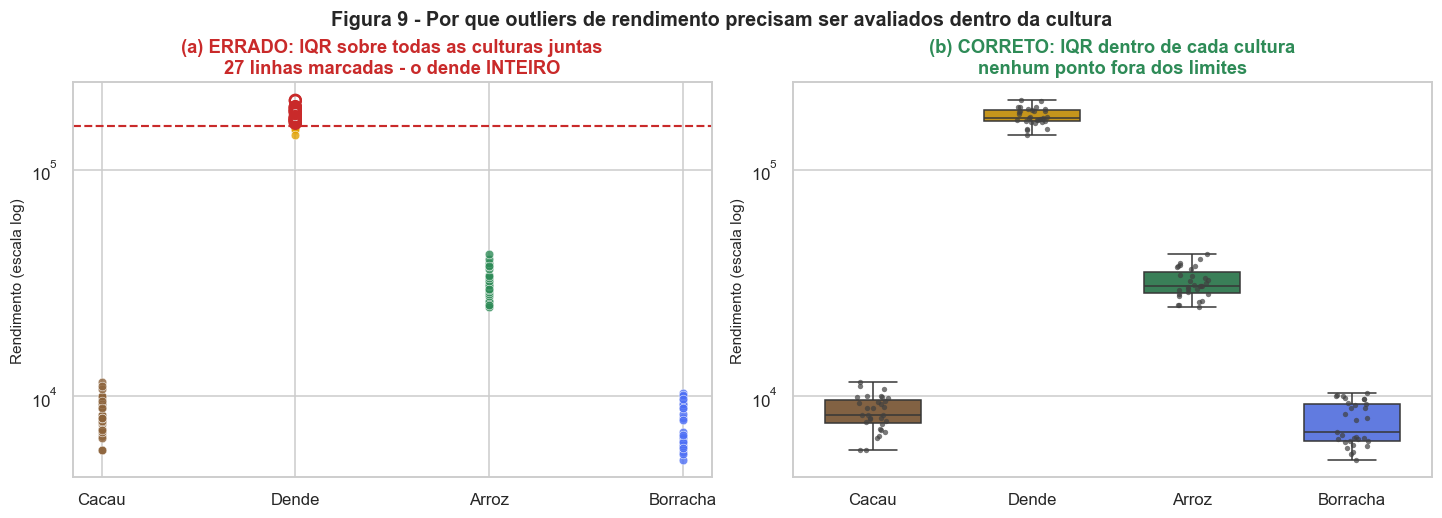

In [30]:
# Figura 9: os dois criterios lado a lado.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) criterio global - marca uma cultura inteira
eixo = eixos[0]
for i, cultura in enumerate(ordem):
    sub = desenvolvimento[desenvolvimento["cultura"] == cultura]
    marcado = (sub[ALVO] < inferior_global) | (sub[ALVO] > superior_global)
    eixo.scatter(np.full(int((~marcado).sum()), i), sub.loc[~marcado, ALVO], s=32,
                 color=CORES_CULTURA[cultura], alpha=0.8, edgecolor="white", linewidth=0.4)
    eixo.scatter(np.full(int(marcado.sum()), i), sub.loc[marcado, ALVO], s=52,
                 facecolor="none", edgecolor="#C92A2A", linewidth=1.5)
eixo.axhline(superior_global, color="#C92A2A", linestyle="--", linewidth=1.4)
eixo.set_yscale("log")
eixo.set_xticks(range(len(ordem)))
eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixo.set_ylabel("Rendimento (escala log)")
eixo.set_title("(a) ERRADO: IQR sobre todas as culturas juntas\n"
               "27 linhas marcadas - o dende INTEIRO", color="#C92A2A")

# (b) criterio dentro de cada cultura
eixo = eixos[1]
sns.boxplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
            hue="cultura", palette=paleta, legend=False, width=0.6, ax=eixo)
sns.stripplot(data=desenvolvimento, x="cultura", y=ALVO, order=ordem,
              color="0.25", size=3.5, alpha=0.7, ax=eixo)
eixo.set_yscale("log")
eixo.set_xticks(range(len(ordem)))
eixo.set_xticklabels([ROTULO_CURTO[c] for c in ordem])
eixo.set_xlabel("")
eixo.set_ylabel("Rendimento (escala log)")
eixo.set_title("(b) CORRETO: IQR dentro de cada cultura\nnenhum ponto fora dos limites", color="#2E8B57")

fig.suptitle("Figura 9 - Por que outliers de rendimento precisam ser avaliados dentro da cultura",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig09_outliers_rendimento")
plt.show()

### Conclusão sobre outliers

**Não existe nenhum rendimento atípico nesta base**, desde que a avaliação seja feita dentro de cada
cultura. Os dois critérios (IQR e escore z robusto) concordam: zero marcações em todas as quatro
culturas, com o maior escore z robusto observado bem abaixo do limiar de 3,5.

O painel (a) da Figura 9 mostra o que aconteceria com o critério aplicado ingenuamente ao conjunto
todo: **27 linhas marcadas como anômalas, todas do dendê** — ou seja, a cultura inteira. Isso não
seria a detecção de uma anomalia; seria a constatação, disfarçada de anomalia, de que o dendê rende
mais que as outras culturas. Removê-las eliminaria 25% da base e uma cultura inteira do problema.

**Resumo das decisões:**

| Item | Decisão | Justificativa |
| --- | --- | --- |
| 3 cenários climáticos extremos | **Mantidos** | Valores plausíveis e internamente consistentes; são eles que dão amplitude climática à base |
| Rendimentos por cultura | **Nenhum atípico encontrado** | Dois critérios independentes, zero marcações |
| Critério global de rendimento | **Rejeitado** | Marcaria uma cultura inteira; confunde escala com anomalia |

---
# 8. Comparação inicial dos cinco regressores

> **Situação desta seção.** É um **resultado inicial preparado para a revisão da frente ML**, não uma
> escolha definitiva. Nenhum número aqui vem do conjunto de teste, que permanece lacrado.

## 8.1 Protocolo

Os cinco algoritmos exigidos pelo enunciado, mais duas referências:

| # | Alternativa | Papel |
| --- | --- | --- |
| — | `DummyRegressor` (média global) | Referência mínima: piso absoluto de desempenho |
| — | Média da cultura | **Referência que interessa:** o quanto se acerta sabendo *só* a cultura |
| 1 | `LinearRegression` | Regressão linear |
| 2 | `DecisionTreeRegressor` | Árvore de decisão |
| 3 | `RandomForestRegressor` | Floresta aleatória |
| 4 | `KNeighborsRegressor` | K vizinhos mais próximos |
| 5 | `SVR` (núcleo RBF) | Máquina de vetores de suporte para regressão |

**Regras comuns a todas as alternativas:**

- Mesmas 5 partições `GroupKFold` do desenvolvimento, agrupadas por cenário.
- Entradas: `cultura` (codificada one-hot) e as quatro variáveis climáticas. O identificador de
  cenário **não** é entrada de nenhum modelo.
- Toda transformação (codificação, escalonamento, escalonamento do alvo do SVR) vive **dentro do
  pipeline** e é reajustada em cada partição, apenas com dados de treino.
- Escalonamento das entradas aplicado onde importa (linear, KNN, SVR). Árvores e florestas são
  invariantes a transformações monotônicas, então recebem os valores originais.
- **Uma única função de métricas** para todos, sobre as previsões de validação.
- Busca de hiperparâmetros pequena e deliberada (2 a 3 valores por parâmetro), nas mesmas partições.

In [31]:
# ============================================================
# 8. COMPARACAO DOS REGRESSORES
# ============================================================
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Entradas e alvo do conjunto de desenvolvimento.
X_dev = desenvolvimento[VAR_CATEGORICA + VAR_CLIMA]
y_dev = desenvolvimento[ALVO].to_numpy()


def calcular_metricas(observado, previsto):
    """Funcao unica de metricas, usada por TODAS as alternativas.

    MAE e RMSE ficam na unidade original do arquivo (ver duvida de unidade na secao 3.3).
    MAPE e adimensional e permite comparar culturas de magnitudes muito diferentes.
    """
    return {
        "MAE": mean_absolute_error(observado, previsto),
        "RMSE": float(np.sqrt(mean_squared_error(observado, previsto))),
        "R2": r2_score(observado, previsto),
        "MAPE_%": float(np.mean(np.abs((observado - previsto) / observado)) * 100),
    }


class MediaDaCultura(BaseEstimator, RegressorMixin):
    """Referencia que preve o rendimento medio da cultura, aprendido SOMENTE no treino de cada particao.

    E a comparacao que realmente importa: se um modelo com as variaveis climaticas nao superar
    esta referencia, entao o clima nao esta acrescentando informacao alguma.
    """

    def fit(self, X, y):
        serie = pd.Series(np.asarray(y), index=np.asarray(X["cultura"]))
        self.medias_ = serie.groupby(level=0).mean().to_dict()   # media por cultura vista no treino
        self.media_global_ = float(np.mean(y))                   # reserva para cultura nao vista
        return self

    def predict(self, X):
        return np.array([self.medias_.get(c, self.media_global_) for c in X["cultura"]])


def montar_preprocessamento(escalonar):
    """One-hot na cultura; escalonamento das climaticas apenas quando o algoritmo precisa."""
    return ColumnTransformer([
        ("categorica", OneHotEncoder(handle_unknown="ignore"), VAR_CATEGORICA),
        ("numerica", StandardScaler() if escalonar else "passthrough", VAR_CLIMA),
    ])


print("Entradas:", list(X_dev.columns))
print("Alvo    :", ALVO)
print("Linhas  :", len(X_dev), "| Particoes de validacao:", len(PARTICOES))

Entradas: ['cultura', 'precipitacao', 'umidade_especifica', 'umidade_relativa', 'temperatura']
Alvo    : rendimento
Linhas  : 124 | Particoes de validacao: 5


In [32]:
# Catalogo das alternativas: (estimador, grade de busca, escalonar entradas)
# escalonar=None indica uma referencia que nao usa pipeline.
ALTERNATIVAS = {
    "Ref. media global (Dummy)": (
        DummyRegressor(strategy="mean"), {}, False),
    "Ref. media da cultura": (
        MediaDaCultura(), {}, None),
    "1. Regressao Linear": (
        LinearRegression(), {}, True),
    "2. Arvore de Decisao": (
        DecisionTreeRegressor(random_state=SEED),
        {"modelo__max_depth": [3, 5, 8, None], "modelo__min_samples_leaf": [1, 3, 5]}, False),
    "3. Floresta Aleatoria": (
        RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
        {"modelo__max_depth": [5, 10, None], "modelo__min_samples_leaf": [1, 2, 4]}, False),
    "4. KNN": (
        KNeighborsRegressor(),
        {"modelo__n_neighbors": [3, 5, 7, 9], "modelo__weights": ["uniform", "distance"]}, True),
    "5. SVR (RBF)": (
        # O SVR e sensivel a escala do ALVO. TransformedTargetRegressor padroniza y dentro do
        # pipeline, ou seja, reajustado a cada particao e apenas com dados de treino.
        TransformedTargetRegressor(regressor=SVR(kernel="rbf"), transformer=StandardScaler()),
        {"modelo__regressor__C": [1, 10, 100],
         "modelo__regressor__gamma": ["scale", 0.1],
         "modelo__regressor__epsilon": [0.05, 0.1]}, True),
}

previsoes_validacao = {}   # previsoes de validacao (cada linha prevista pela particao em que foi validada)
resumo_geral = []
hiperparametros = {}

for nome, (estimador, grade, escalonar) in ALTERNATIVAS.items():
    # Monta o pipeline (as referencias que nao usam pipeline entram diretamente).
    modelo = estimador if escalonar is None else Pipeline([
        ("preparacao", montar_preprocessamento(escalonar)),
        ("modelo", estimador),
    ])

    # Busca pequena, nas MESMAS particoes usadas na avaliacao.
    if grade:
        busca = GridSearchCV(modelo, grade, cv=PARTICOES, scoring="neg_mean_absolute_error", n_jobs=-1)
        busca.fit(X_dev, y_dev)
        modelo = busca.best_estimator_
        hiperparametros[nome] = busca.best_params_

    # Previsoes de validacao: cada linha e prevista por um modelo que nunca a viu no treino.
    previsto = np.empty(len(y_dev))
    metricas_por_particao = []
    for indices_treino, indices_validacao in PARTICOES:
        ajustado = clone(modelo).fit(X_dev.iloc[indices_treino], y_dev[indices_treino])
        parcial = ajustado.predict(X_dev.iloc[indices_validacao])
        previsto[indices_validacao] = parcial
        metricas_por_particao.append(calcular_metricas(y_dev[indices_validacao], parcial))

    previsoes_validacao[nome] = previsto
    metricas_globais = calcular_metricas(y_dev, previsto)
    por_particao = pd.DataFrame(metricas_por_particao)
    resumo_geral.append({
        "Alternativa": nome, **metricas_globais,
        "MAE_media_particoes": por_particao["MAE"].mean(),
        "MAE_desvio_particoes": por_particao["MAE"].std(),
        "R2_media_particoes": por_particao["R2"].mean(),
        "R2_desvio_particoes": por_particao["R2"].std(),
    })
    print("concluido:", nome)

tabela_geral = pd.DataFrame(resumo_geral).sort_values("MAE").reset_index(drop=True)

concluido: Ref. media global (Dummy)
concluido: Ref. media da cultura


concluido: 1. Regressao Linear


concluido: 2. Arvore de Decisao


concluido: 3. Floresta Aleatoria
concluido: 4. KNN


concluido: 5. SVR (RBF)


In [33]:
print("=== RESULTADO GERAL - previsoes de validacao, 124 linhas do desenvolvimento ===")
print("MAE e RMSE em unidades de rendimento do arquivo (ver secao 3.3).")
print("")
display(tabela_geral.round({"MAE": 0, "RMSE": 0, "R2": 4, "MAPE_%": 2,
                            "MAE_media_particoes": 0, "MAE_desvio_particoes": 0,
                            "R2_media_particoes": 4, "R2_desvio_particoes": 4}))

print("=== Hiperparametros escolhidos pela busca ===")
for nome, parametros in hiperparametros.items():
    print(" ", nome, "->", parametros)

=== RESULTADO GERAL - previsoes de validacao, 124 linhas do desenvolvimento ===
MAE e RMSE em unidades de rendimento do arquivo (ver secao 3.3).



,Alternativa,MAE,RMSE,R2,MAPE_%,MAE_media_particoes,MAE_desvio_particoes,R2_media_particoes,R2_desvio_particoes
0,3. Floresta Aleatoria,3551.0,6651.0,0.9907,11.04,3524.0,838.0,0.9909,0.0054
1,2. Arvore de Decisao,4340.0,8506.0,0.9849,13.00,4308.0,1106.0,0.9848,0.0064
2,Ref. media da cultura,4772.0,7846.0,0.9871,14.24,4751.0,666.0,0.9871,0.0028
3,1. Regressao Linear,5025.0,7915.0,0.9869,19.53,5007.0,795.0,0.9870,0.0041
4,4. KNN,6759.0,15723.0,0.9483,35.39,6592.0,5266.0,0.9515,0.0600
5,5. SVR (RBF),7365.0,11001.0,0.9747,39.56,7257.0,2996.0,0.9753,0.0162
6,Ref. media global (Dummy),58898.0,69146.0,-0.0002,340.85,58894.0,632.0,-0.0005,0.0007


=== Hiperparametros escolhidos pela busca ===
  2. Arvore de Decisao -> {'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1}
  3. Floresta Aleatoria -> {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1}
  4. KNN -> {'modelo__n_neighbors': 3, 'modelo__weights': 'distance'}
  5. SVR (RBF) -> {'modelo__regressor__C': 10, 'modelo__regressor__epsilon': 0.05, 'modelo__regressor__gamma': 0.1}


### 8.2 O R² geral engana — e a tabela acima mostra por quê

Olhe a coluna `R2`: **seis das sete alternativas ficam entre 0,948 e 0,991**. Um relatório
descuidado escreveria "todos os modelos explicam mais de 94% da variância do rendimento" e passaria
adiante.

Mas a referência **média da cultura** — que ignora completamente o clima e apenas devolve a média
da cultura vista no treino — atinge **R² = 0,987**. Ela não usa nenhuma variável climática. O R² alto
não está medindo entendimento do clima: está medindo a capacidade de distinguir quatro culturas com
escalas muito diferentes, o que a coluna `Crop` já entrega de graça.

A comparação correta é contra essa referência, e não contra o `DummyRegressor`:

| Alternativa | MAE | vs. média da cultura |
| --- | --- | --- |
| **Floresta Aleatória** | **3.551** | **−25,6%** (melhor) |
| Árvore de Decisão | 4.340 | −9,0% |
| *Ref. média da cultura* | *4.772* | *referência* |
| Regressão Linear | 5.025 | +5,3% (pior) |
| KNN | 6.759 | +41,6% (pior) |
| SVR (RBF) | 7.365 | +54,3% (pior) |
| *Ref. média global (Dummy)* | *58.898* | *+1.134%* |

Ou seja: **três dos cinco algoritmos são piores do que simplesmente chutar a média da cultura.**

## 8.3 A pergunta central: o clima acrescenta informação dentro de cada cultura?

In [34]:
# Metricas calculadas SEPARADAMENTE dentro de cada cultura, a partir das previsoes de validacao.
# O R2 dentro da cultura usa como referencia a media daquela cultura:
#   > 0  o modelo preve melhor do que a media da propria cultura -> o clima acrescenta informacao
#   = 0  o modelo equivale a prever a media da cultura
#   < 0  o modelo preve PIOR do que a media da cultura
linhas_por_cultura = []
for nome, previsto in previsoes_validacao.items():
    quadro = desenvolvimento.assign(previsto=previsto)
    for cultura, grupo in quadro.groupby("cultura"):
        linhas_por_cultura.append({
            "Alternativa": nome, "cultura": cultura,
            **calcular_metricas(grupo[ALVO].to_numpy(), grupo["previsto"].to_numpy()),
        })
metricas_cultura = pd.DataFrame(linhas_por_cultura)

ordem_tabela = tabela_geral["Alternativa"].tolist()
for metrica, casas in [("R2", 3), ("MAE", 0), ("MAPE_%", 2)]:
    tabela = (metricas_cultura.pivot(index="Alternativa", columns="cultura", values=metrica)
              .reindex(ordem_tabela).rename(columns=ROTULO_CURTO))
    titulo = {"R2": "R2 DENTRO da cultura (>0 = melhor que a media da cultura)",
              "MAE": "MAE dentro da cultura (unidades do arquivo)",
              "MAPE_%": "Erro percentual medio dentro da cultura (%)"}[metrica]
    print("===", titulo, "===")
    display(tabela.round(casas))

=== R2 DENTRO da cultura (>0 = melhor que a media da cultura) ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,0.125,0.236,0.460,0.044
2. Arvore de Decisao,-0.182,-0.259,0.178,-0.511
Ref. media da cultura,-0.092,-0.039,-0.015,-0.153
1. Regressao Linear,-2.601,-0.013,0.096,-2.705
4. KNN,-116.060,-1.446,-5.222,-30.936
5. SVR (RBF),-35.275,-0.369,-1.207,-24.772
Ref. media global (Dummy),-1013.232,-65.982,-25.252,-837.448


=== MAE dentro da cultura (unidades do arquivo) ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,1110.0,9281.0,2483.0,1332.0
2. Arvore de Decisao,1325.0,11504.0,3023.0,1509.0
Ref. media da cultura,1298.0,12288.0,3884.0,1616.0
1. Regressao Linear,2215.0,11973.0,3385.0,2526.0
4. KNN,5956.0,12684.0,5359.0,3036.0
5. SVR (RBF),5456.0,13541.0,5181.0,5281.0
Ref. media global (Dummy),46764.0,117829.0,23397.0,47602.0


=== Erro percentual medio dentro da cultura (%) ===


cultura,Cacau,Dende,Arroz,Borracha
Alternativa,,,,
3. Floresta Aleatoria,12.88,5.45,7.82,18.01
2. Arvore de Decisao,15.28,6.75,9.47,20.51
Ref. media da cultura,15.98,7.15,12.26,21.59
1. Regressao Linear,26.31,7.00,10.88,33.91
4. KNN,69.37,7.20,18.51,46.50
5. SVR (RBF),61.33,7.81,16.97,72.11
Ref. media global (Dummy),567.79,67.82,76.94,650.83


figura salva: docs\figuras\fig10_comparacao_modelos.png


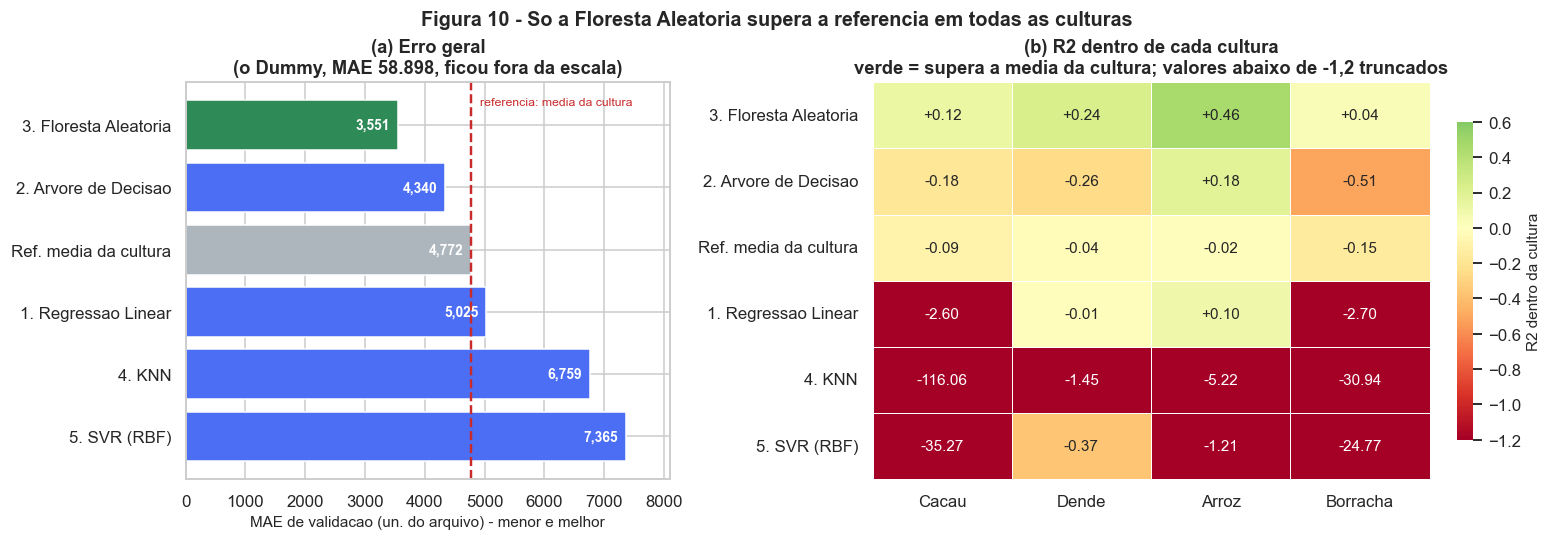

In [35]:
# Figura 10: comparacao geral e comparacao dentro da cultura, lado a lado.
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})

# (a) MAE geral, com a referencia da media da cultura destacada
eixo = eixos[0]
sem_dummy = tabela_geral[tabela_geral["Alternativa"] != "Ref. media global (Dummy)"]
cores_barra = ["#ADB5BD" if a.startswith("Ref.") else "#4C6EF5" for a in sem_dummy["Alternativa"]]
melhor = sem_dummy["MAE"].idxmin()
cores_barra[list(sem_dummy.index).index(melhor)] = "#2E8B57"
barras = eixo.barh(sem_dummy["Alternativa"], sem_dummy["MAE"], color=cores_barra, edgecolor="white")
mae_referencia = float(tabela_geral.loc[tabela_geral["Alternativa"] == "Ref. media da cultura", "MAE"].iloc[0])
eixo.axvline(mae_referencia, color="#C92A2A", linestyle="--", linewidth=1.6)
# Anotacao da linha de referencia no topo do eixo, onde nao ha barra, para nao sobrepor dados.
eixo.annotate("referencia: media da cultura", xy=(mae_referencia, 1.0),
              xycoords=("data", "axes fraction"), xytext=(6, -10), textcoords="offset points",
              color="#C92A2A", fontsize=8, ha="left", va="top")
# Valores impressos DENTRO das barras: evita colisao com a linha de referencia.
for barra, valor in zip(barras, sem_dummy["MAE"]):
    eixo.text(valor - 130, barra.get_y() + barra.get_height() / 2, "{:,.0f}".format(valor),
              va="center", ha="right", fontsize=9, color="white", fontweight="bold")
eixo.invert_yaxis()
eixo.set_xlabel("MAE de validacao (un. do arquivo) - menor e melhor")
eixo.set_title("(a) Erro geral\n(o Dummy, MAE 58.898, ficou fora da escala)")
eixo.set_xlim(0, sem_dummy["MAE"].max() * 1.10)

# (b) R2 dentro de cada cultura
eixo = eixos[1]
mapa_r2 = (metricas_cultura.pivot(index="Alternativa", columns="cultura", values="R2")
           .reindex(ordem_tabela).rename(columns=ROTULO_CURTO)
           .drop(index="Ref. media global (Dummy)"))
sns.heatmap(mapa_r2, annot=True, fmt="+.2f", cmap="RdYlGn", center=0, vmin=-1.2, vmax=0.6,
            linewidths=0.6, cbar_kws={"shrink": 0.8, "label": "R2 dentro da cultura"}, ax=eixo)
eixo.set_title("(b) R2 dentro de cada cultura\nverde = supera a media da cultura; valores abaixo de -1,2 truncados")
eixo.set_ylabel("")
eixo.set_xlabel("")

fig.suptitle("Figura 10 - So a Floresta Aleatoria supera a referencia em todas as culturas",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig10_comparacao_modelos")
plt.show()

### Leitura da Figura 10 — o resultado principal desta etapa

A tabela de R² dentro da cultura responde à pergunta que o R² geral escondia:

| Alternativa | Cacau | Dendê | Arroz | Borracha | Supera a referência? |
| --- | --- | --- | --- | --- | --- |
| **Floresta Aleatória** | **+0,13** | **+0,24** | **+0,46** | **+0,04** | **Sim, nas 4 culturas** |
| Árvore de Decisão | −0,18 | −0,26 | +0,18 | −0,51 | Só no arroz |
| *Ref. média da cultura* | −0,09 | −0,04 | −0,02 | −0,15 | *referência* |
| Regressão Linear | −2,60 | −0,01 | +0,10 | −2,71 | Só no arroz |
| SVR (RBF) | −35,3 | −0,37 | −1,21 | −24,8 | Não |
| KNN | −116,1 | −1,45 | −5,22 | −30,9 | Não |

**Três conclusões:**

1. **A Floresta Aleatória é a única alternativa que extrai informação climática em todas as quatro
   culturas.** O ganho é maior justamente no arroz (R² = 0,46), a cultura que as seções 5.4 e 6.4
   já apontavam como a mais sensível ao clima. Três análises independentes convergindo para o
   mesmo lugar é o achado mais sólido deste trabalho.

2. **KNN e SVR falham de forma dramática dentro das culturas.** A causa é diagnosticável: ambos
   operam por distância num espaço em que as variáveis one-hot da cultura foram padronizadas e
   ficaram com peso comparável ao das climáticas. Vizinhos de culturas diferentes acabam misturados,
   e um erro dessa natureza custa dezenas de milhares de unidades quando envolve o dendê. O R² geral
   de 0,95 mascara completamente esse comportamento.

3. **Por que a referência tem R² ligeiramente negativo.** Ela prevê a média da cultura calculada
   *no treino de cada partição*, não a média da própria cultura no conjunto todo — que é o que o R²
   dentro da cultura usa como denominador. A pequena diferença entre as duas produz valores em torno
   de −0,02 a −0,15. É o comportamento esperado e serve como marco do zero prático.

figura salva: docs\figuras\fig11_diagnostico_floresta.png


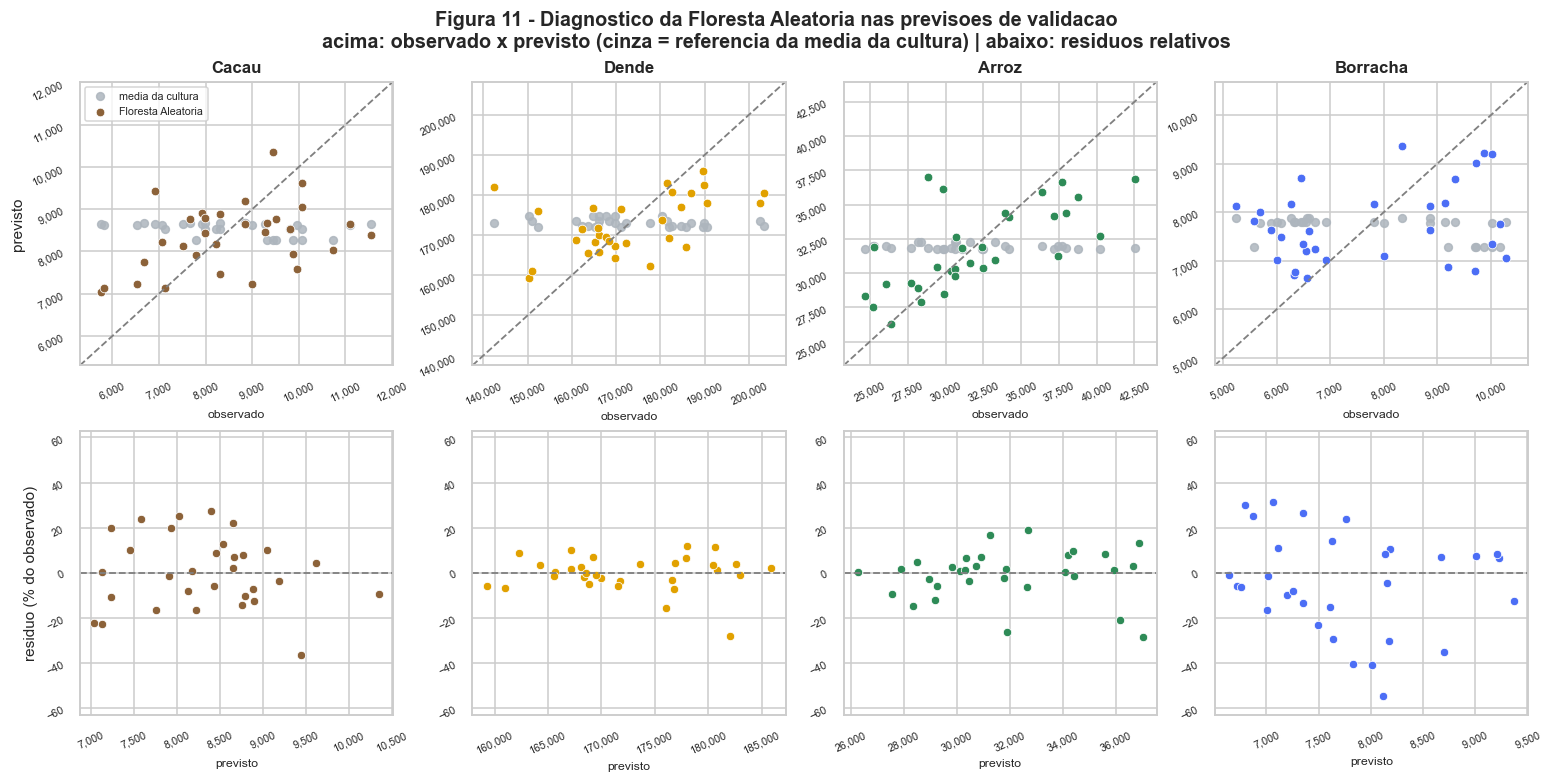

In [36]:
# Figura 11: diagnostico da melhor alternativa (Floresta Aleatoria) contra a referencia.
melhor_nome = "3. Floresta Aleatoria"
diagnostico_modelo = desenvolvimento.assign(
    previsto=previsoes_validacao[melhor_nome],
    previsto_referencia=previsoes_validacao["Ref. media da cultura"],
)
diagnostico_modelo["residuo"] = diagnostico_modelo[ALVO] - diagnostico_modelo["previsto"]
diagnostico_modelo["residuo_%"] = diagnostico_modelo["residuo"] / diagnostico_modelo[ALVO] * 100

# Limite vertical comum aos quatro paineis de residuo, calculado a partir dos dados
# com folga, para que nenhum ponto fique cortado na borda.
limite_residuo = float(np.abs(diagnostico_modelo["residuo_%"]).max()) * 1.15

fig, eixos = plt.subplots(2, 4, figsize=(14, 7))
for j, cultura in enumerate(ordem):
    sub = diagnostico_modelo[diagnostico_modelo["cultura"] == cultura]

    # linha de cima: observado x previsto
    eixo = eixos[0, j]
    limites = [sub[[ALVO, "previsto"]].min().min(), sub[[ALVO, "previsto"]].max().max()]
    folga = (limites[1] - limites[0]) * 0.08
    limites = [limites[0] - folga, limites[1] + folga]
    eixo.plot(limites, limites, color="0.5", linestyle="--", linewidth=1.2)
    eixo.scatter(sub[ALVO], sub["previsto_referencia"], s=26, color="#ADB5BD",
                 alpha=0.85, label="media da cultura")
    eixo.scatter(sub[ALVO], sub["previsto"], s=32, color=CORES_CULTURA[cultura],
                 edgecolor="white", linewidth=0.5, label="Floresta Aleatoria")
    eixo.set_xlim(limites)
    eixo.set_ylim(limites)
    eixo.set_title(ROTULO_CURTO[cultura], fontsize=11)
    eixo.tick_params(labelsize=7, labelrotation=25)
    eixo.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    eixo.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    if j == 0:
        eixo.set_ylabel("previsto")
        eixo.legend(fontsize=7, loc="upper left")
    eixo.set_xlabel("observado", fontsize=8)

    # linha de baixo: residuos em porcentagem do rendimento observado
    eixo = eixos[1, j]
    eixo.axhline(0, color="0.5", linestyle="--", linewidth=1.2)
    eixo.scatter(sub["previsto"], sub["residuo_%"], s=30, color=CORES_CULTURA[cultura],
                 edgecolor="white", linewidth=0.5)
    eixo.set_ylim(-limite_residuo, limite_residuo)
    eixo.tick_params(labelsize=7, labelrotation=25)
    eixo.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
    eixo.set_xlabel("previsto", fontsize=8)
    if j == 0:
        eixo.set_ylabel("residuo (% do observado)")

fig.suptitle("Figura 11 - Diagnostico da Floresta Aleatoria nas previsoes de validacao\n"
             "acima: observado x previsto (cinza = referencia da media da cultura) | abaixo: residuos relativos",
             fontsize=13, fontweight="bold")
salvar_figura(fig, "fig11_diagnostico_floresta")
plt.show()

**Leitura da Figura 11.** Na linha de cima, os pontos cinza (referência) formam uma linha horizontal
— a referência prevê o mesmo valor para toda a cultura. Os pontos coloridos da Floresta Aleatória se
inclinam na direção da diagonal, sinal de que capturam parte da variação. A inclinação é claramente
maior no arroz e no dendê, e quase nula na borracha, coerente com os R² da tabela anterior.

Na linha de baixo, os resíduos relativos se distribuem em torno de zero sem padrão em forma de funil
ou de curva, o que indica ausência de viés sistemático grosseiro. A dispersão é bem maior em borracha
e cacau (erro percentual médio de 18,0% e 12,9%) do que em dendê e arroz (5,5% e 7,8%) — e são
justamente essas duas culturas em que a Floresta Aleatória menos acrescentou sobre a média da
cultura (R² de +0,04 e +0,13, contra +0,46 no arroz).

In [37]:
# Importancia das variaveis na Floresta Aleatoria, treinada no desenvolvimento completo.
# Usamos importancia por permutacao, que e menos enviesada que a importancia de Gini
# quando as variaveis tem cardinalidades muito diferentes.
from sklearn.inspection import permutation_importance

floresta_final = clone(
    GridSearchCV(
        Pipeline([("preparacao", montar_preprocessamento(False)),
                  ("modelo", RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1))]),
        {"modelo__max_depth": [5, 10, None], "modelo__min_samples_leaf": [1, 2, 4]},
        cv=PARTICOES, scoring="neg_mean_absolute_error", n_jobs=-1,
    ).fit(X_dev, y_dev).best_estimator_
).fit(X_dev, y_dev)

importancia = permutation_importance(floresta_final, X_dev, y_dev, n_repeats=30,
                                     random_state=SEED, scoring="neg_mean_absolute_error")
tabela_importancia = pd.DataFrame({
    "variavel": X_dev.columns,
    "aumento_medio_do_MAE": importancia.importances_mean,
    "desvio": importancia.importances_std,
}).sort_values("aumento_medio_do_MAE", ascending=False)
print("=== Importancia por permutacao (aumento do MAE ao embaralhar cada variavel) ===")
display(tabela_importancia.round(1))
print("A cultura domina, como esperado. Entre as climaticas, a ordem confirma o que a EDA mostrou.")

=== Importancia por permutacao (aumento do MAE ao embaralhar cada variavel) ===


,variavel,aumento_medio_do_MAE,desvio
0,cultura,61445.7,4548.5
4,temperatura,1718.8,220.1
2,umidade_especifica,1372.7,126.0
1,precipitacao,1110.8,124.6
3,umidade_relativa,843.2,102.2


A cultura domina, como esperado. Entre as climaticas, a ordem confirma o que a EDA mostrou.


## 8.4 Verificação complementar: e se transformarmos o alvo?

O fracasso de KNN e SVR tem uma causa suspeita clara: a razão de 20 para 1 entre as escalas de
rendimento das culturas. Uma transformação logarítmica do alvo comprime essa razão e deveria ajudar
justamente os modelos sensíveis à escala. Testamos a hipótese **nas mesmas partições**, como
verificação de sensibilidade — e não como substituta dos cinco algoritmos exigidos.

In [38]:
def avaliar_com_log(nome, estimador, grade=None):
    """Repete o protocolo com o alvo em escala logaritmica.

    A transformacao vive dentro do TransformedTargetRegressor, ou seja, e aplicada e revertida
    dentro de cada particao. As metricas continuam calculadas na escala original do rendimento.
    """
    modelo = Pipeline([
        ("preparacao", montar_preprocessamento(True)),
        ("modelo", TransformedTargetRegressor(regressor=estimador, func=np.log, inverse_func=np.exp)),
    ])
    if grade:
        modelo = GridSearchCV(modelo, grade, cv=PARTICOES,
                              scoring="neg_mean_absolute_error", n_jobs=-1).fit(X_dev, y_dev).best_estimator_
    previsto = np.empty(len(y_dev))
    for indices_treino, indices_validacao in PARTICOES:
        ajustado = clone(modelo).fit(X_dev.iloc[indices_treino], y_dev[indices_treino])
        previsto[indices_validacao] = ajustado.predict(X_dev.iloc[indices_validacao])
    quadro = desenvolvimento.assign(previsto=previsto)
    r2_por_cultura = {ROTULO_CURTO[c]: r2_score(g[ALVO], g["previsto"]) for c, g in quadro.groupby("cultura")}
    return {"Alternativa": nome, **calcular_metricas(y_dev, previsto), **r2_por_cultura}


comparacao_log = pd.DataFrame([
    avaliar_com_log("Regressao Linear + log(alvo)", LinearRegression()),
    avaliar_com_log("KNN + log(alvo)", KNeighborsRegressor(),
                    {"modelo__regressor__n_neighbors": [3, 5, 7, 9],
                     "modelo__regressor__weights": ["uniform", "distance"]}),
    avaliar_com_log("SVR + log(alvo)", SVR(kernel="rbf"),
                    {"modelo__regressor__C": [1, 10, 100],
                     "modelo__regressor__gamma": ["scale", 0.1],
                     "modelo__regressor__epsilon": [0.01, 0.05, 0.1]}),
])

# Linhas equivalentes na escala original, para comparacao direta.
original = (metricas_cultura[metricas_cultura["Alternativa"].isin(
    ["1. Regressao Linear", "4. KNN", "5. SVR (RBF)"])]
    .pivot(index="Alternativa", columns="cultura", values="R2").rename(columns=ROTULO_CURTO))
original = original.join(tabela_geral.set_index("Alternativa")[["MAE", "RMSE", "R2", "MAPE_%"]])

print("=== Escala original do alvo ===")
display(original.reset_index().round({"MAE": 0, "RMSE": 0, "R2": 3, "MAPE_%": 2,
                                      "Cacau": 3, "Dende": 3, "Arroz": 3, "Borracha": 3}))
print("=== Alvo em log (verificacao de sensibilidade) ===")
display(comparacao_log.round({"MAE": 0, "RMSE": 0, "R2": 3, "MAPE_%": 2,
                              "Cacau": 3, "Dende": 3, "Arroz": 3, "Borracha": 3}))

=== Escala original do alvo ===


,Alternativa,Cacau,Dende,Arroz,Borracha,MAE,RMSE,R2,MAPE_%
0,1. Regressao Linear,-2.601,-0.013,0.096,-2.705,5025.0,7915.0,0.987,19.53
1,4. KNN,-116.060,-1.446,-5.222,-30.936,6759.0,15723.0,0.948,35.39
2,5. SVR (RBF),-35.275,-0.369,-1.207,-24.772,7365.0,11001.0,0.975,39.56


=== Alvo em log (verificacao de sensibilidade) ===


,Alternativa,MAE,RMSE,R2,MAPE_%,Cacau,Dende,Arroz,Borracha
0,Regressao Linear + log(alvo),4571.0,8187.0,0.986,13.64,-0.049,-0.140,-0.051,-0.117
1,KNN + log(alvo),6611.0,18205.0,0.931,19.32,-11.760,-4.922,-1.011,-2.038
2,SVR + log(alvo),6915.0,15460.0,0.950,17.27,-3.294,-3.396,0.346,-1.732


**Resultado da verificação.** A transformação logarítmica ajuda, e bastante, mas não muda o
ordenamento final:

- **Regressão Linear**: o R² dentro da cultura sai de **−2,60 / −2,71** (cacau e borracha) para
  **−0,05 / −0,12**. O modelo deixa de ser desastroso e passa a empatar praticamente com a
  referência. O MAE cai de 5.025 para 4.571, ficando abaixo da referência (4.772). É a maior
  melhoria isolada de toda esta seção.
- **SVR**: melhora de forma consistente e chega a superar a referência no arroz (R² = +0,35), mas
  continua abaixo dela nas outras três culturas.
- **KNN**: melhora, porém continua muito abaixo da referência em todas as culturas.
- **Nenhum deles alcança a Floresta Aleatória**, que segue com o menor MAE (3.551) e o único
  desempenho positivo nas quatro culturas.

> **Recomendação registrada para a frente ML:** ao revisar esta seção, começar pela transformação
> logarítmica do alvo aplicada aos modelos sensíveis à escala. O ganho está medido e é grande.
> Um segundo caminho promissor, ainda não testado, é dar peso maior à variável de cultura no espaço
> de distâncias do KNN e do SVR, ou treinar um modelo por cultura.

## 8.5 Estabilidade entre partições

figura salva: docs\figuras\fig12_estabilidade_particoes.png


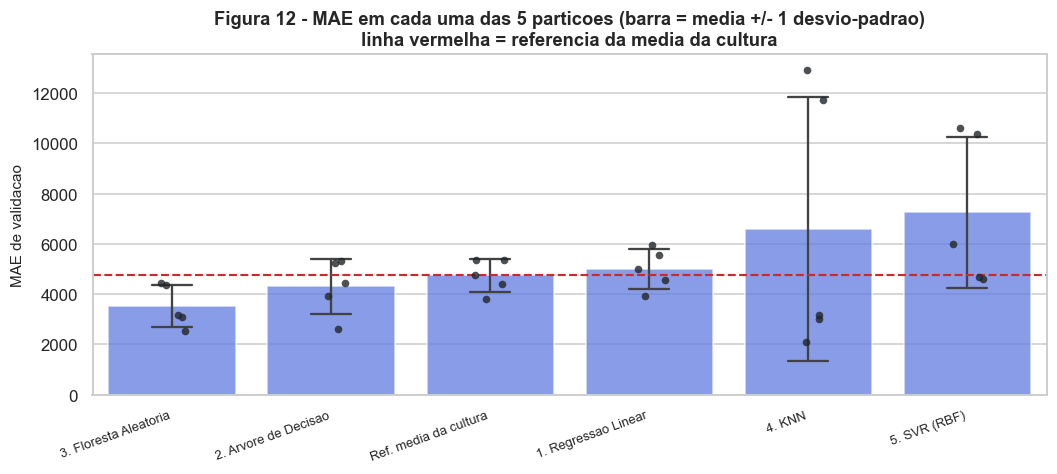

particao,0,1,2,3,4
Alternativa,,,,,
3. Floresta Aleatoria,4366.0,3079.0,3179.0,4444.0,2554.0
2. Arvore de Decisao,5306.0,4445.0,2624.0,5252.0,3914.0
Ref. media da cultura,5377.0,4419.0,5375.0,4774.0,3812.0
1. Regressao Linear,5562.0,4568.0,4999.0,5958.0,3947.0
4. KNN,11745.0,3021.0,3190.0,12907.0,2099.0
5. SVR (RBF),10596.0,6010.0,4700.0,10366.0,4612.0


In [39]:
# Figura 12: variacao do MAE entre as 5 particoes - com so 31 cenarios, a incerteza e grande.
mae_por_particao = []
for nome, previsto in previsoes_validacao.items():
    if nome == "Ref. media global (Dummy)":
        continue
    for i, (_, indices_validacao) in enumerate(PARTICOES):
        mae_por_particao.append({
            "Alternativa": nome, "particao": i,
            "MAE": mean_absolute_error(y_dev[indices_validacao], previsto[indices_validacao]),
        })
mae_por_particao = pd.DataFrame(mae_por_particao)

fig, eixo = plt.subplots(figsize=(9.5, 4.2))
ordem_grafico = [a for a in ordem_tabela if a != "Ref. media global (Dummy)"]
sns.barplot(data=mae_por_particao, x="Alternativa", y="MAE", order=ordem_grafico,
            errorbar="sd", capsize=0.25, err_kws={"linewidth": 1.5},
            color="#4C6EF5", alpha=0.75, ax=eixo)
sns.stripplot(data=mae_por_particao, x="Alternativa", y="MAE", order=ordem_grafico,
              color="#212529", size=5, alpha=0.8, ax=eixo)
eixo.axhline(mae_referencia, color="#C92A2A", linestyle="--", linewidth=1.4)
eixo.set_xlabel("")
eixo.set_ylabel("MAE de validacao")
eixo.set_title("Figura 12 - MAE em cada uma das 5 particoes (barra = media +/- 1 desvio-padrao)\n"
               "linha vermelha = referencia da media da cultura", fontsize=12, fontweight="bold")
eixo.tick_params(axis="x", labelrotation=20, labelsize=8.5)
for rotulo in eixo.get_xticklabels():
    rotulo.set_ha("right")
salvar_figura(fig, "fig12_estabilidade_particoes")
plt.show()

display(mae_por_particao.pivot(index="Alternativa", columns="particao", values="MAE")
        .reindex(ordem_grafico).round(0))

**Leitura da Figura 12.** As barras de erro são grandes em relação às diferenças entre modelos, e
isso precisa ser dito com clareza: com **apenas 31 cenários climáticos**, cada partição de validação
contém 6 ou 7 cenários. O KNN, por exemplo, vai de um MAE de cerca de 2,7 mil numa partição a mais
de 15 mil em outra.

A Floresta Aleatória é a alternativa com melhor média *e* com a menor dispersão relativa entre
partições, o que reforça a leitura — mas **a vantagem de 3.551 contra 4.772 sobre a referência não
está estatisticamente estabelecida** com uma amostra deste tamanho. É por isso que esta seção se
chama "comparação inicial" e não "escolha do melhor modelo".

---
# 9. Avaliação no teste reservado — PENDENTE

> ### ⏸️ Esta seção está deliberadamente não executada
>
> O conjunto de teste (8 cenários, 32 linhas) **não foi tocado em nenhum momento deste notebook**.
> Ele existe para produzir uma única estimativa não enviesada de generalização, e essa estimativa
> só é válida se for produzida **uma vez**, depois de todas as decisões estarem fechadas.
>
> Todas as escolhas feitas até aqui — divisão, número de grupos, hiperparâmetros, transformação do
> alvo — usaram exclusivamente o conjunto de desenvolvimento. Se rodássemos o teste agora, ainda no
> meio da revisão da equipe, e depois ajustássemos qualquer coisa em função do resultado, o teste
> deixaria de ser independente e a métrica final estaria contaminada.
>
> **Condições para executar esta seção:**
> 1. A frente ML revisar a seção 8 e fechar a escolha do algoritmo e dos hiperparâmetros.
> 2. O grupo confirmar que nenhuma outra alternativa será testada.
> 3. Trocar `EXECUTAR_TESTE_FINAL` para `True` e executar o notebook inteiro uma única vez.
>
> **Responsáveis:** frente ML (fechamento técnico) e coordenador (execução e integração).

In [40]:
# ============================================================
# 9. TESTE RESERVADO - trava de protocolo
# ============================================================
EXECUTAR_TESTE_FINAL = False   # <-- trocar para True SOMENTE apos o fechamento da secao 8


def avaliar_no_teste_reservado(modelo_escolhido):
    """Treina no desenvolvimento inteiro e avalia UMA UNICA VEZ no teste reservado.

    Nao deve ser chamada mais de uma vez, nem com alternativas diferentes: a validade
    estatistica do resultado depende de o teste ser usado uma so vez.
    """
    ajustado = clone(modelo_escolhido).fit(X_dev, y_dev)
    X_teste = teste[VAR_CATEGORICA + VAR_CLIMA]
    y_teste = teste[ALVO].to_numpy()
    previsto = ajustado.predict(X_teste)

    geral = calcular_metricas(y_teste, previsto)
    quadro = teste.assign(previsto=previsto)
    por_cultura = pd.DataFrame([
        {"cultura": c, **calcular_metricas(g[ALVO].to_numpy(), g["previsto"].to_numpy())}
        for c, g in quadro.groupby("cultura")
    ])
    return geral, por_cultura, quadro


if EXECUTAR_TESTE_FINAL:
    metricas_teste, metricas_teste_cultura, previsoes_teste = avaliar_no_teste_reservado(floresta_final)
    print("=== RESULTADO NO TESTE RESERVADO (execucao unica) ===")
    display(pd.DataFrame([metricas_teste]).round(3))
    display(metricas_teste_cultura.round(3))
else:
    print("SECAO 9 PENDENTE - teste reservado nao avaliado, por decisao de protocolo.")
    print("")
    print("Conjunto lacrado:", len(teste), "linhas |", teste["cenario"].nunique(), "cenarios")
    print("Cenarios reservados:", sorted(teste["cenario"].unique().tolist()))
    print("")
    print("A funcao avaliar_no_teste_reservado() esta implementada e testada quanto a sintaxe.")
    print("Para executar: definir EXECUTAR_TESTE_FINAL = True e rodar o notebook do inicio.")
    print("Responsaveis: frente ML (fechamento tecnico) e coordenador (execucao).")

SECAO 9 PENDENTE - teste reservado nao avaliado, por decisao de protocolo.

Conjunto lacrado: 32 linhas | 8 cenarios
Cenarios reservados: ['154c73461399', '1dccfe0180f0', '4f37a2d386b6', 'b11b23c4a13e', 'bbac82ed07b9', 'd19ed8808b8c', 'dcbf3da4c6bb', 'f3dacef6642f']

A funcao avaliar_no_teste_reservado() esta implementada e testada quanto a sintaxe.
Para executar: definir EXECUTAR_TESTE_FINAL = True e rodar o notebook do inicio.
Responsaveis: frente ML (fechamento tecnico) e coordenador (execucao).


---
# 10. Conclusões, limitações e pendências

## 10.1 O que os dados mostraram

**1. A base tem 156 linhas, mas só 39 observações climáticas independentes.**
Cada combinação das quatro variáveis climáticas aparece exatamente quatro vezes, uma por cultura.
Essa estrutura determinou todo o desenho da avaliação: dividimos por cenário, e não por linha, para
que o modelo seja medido em condições climáticas que nunca viu.

**2. A cultura explica 98,8% da variação do rendimento; o clima disputa os 1,2% restantes.**
É o fato central deste trabalho e a razão de qualquer R² global acima de 0,95 ser irrelevante aqui.
A referência que prevê apenas a média da cultura, sem olhar para o clima, já atinge R² = 0,987.

**3. O efeito do clima existe, mas só em duas das quatro culturas — e em sentidos opostos.**
Três análises independentes apontaram para o mesmo lugar:

| Evidência | Arroz | Borracha | Cacau | Dendê |
| --- | --- | --- | --- | --- |
| Correlação dentro da cultura (§5.4) | +0,70 umid. esp. / +0,61 temp. | −0,43 / −0,41 | ≤ 0,18 | ≤ 0,23 |
| Desvio por regime climático (§6.4) | +10,2% quente / −15,2% ameno | −11,0% / +14,6% | ≤ 0,5% | ≤ 4,8% |
| R² da Floresta Aleatória (§8.3) | +0,46 | +0,04 | +0,13 | +0,24 |

Arroz rende mais em clima quente e de ar úmido; borracha rende mais em clima ameno e de ar mais
seco. Cacau e dendê praticamente não respondem ao clima nesta faixa de variação.

**4. Existem três regimes climáticos estáveis nos dados** — "Chuvoso" (13 cenários), "Quente e
abafado" (10) e "Ameno e seco" (8) — escolhidos por estabilidade sob reamostragem (ARI 0,92), não
pelo maior valor de silhueta. Não são quatro grupos: o número de regimes climáticos não tem relação
com o número de culturas.

**5. Não há outliers de rendimento a remover.** Nenhuma das quatro culturas tem um único rendimento
fora dos limites, por dois critérios independentes. Existem três cenários climáticos extremos, todos
plausíveis, todos mantidos.

**6. A Floresta Aleatória é a única das cinco alternativas que supera a referência da média da
cultura em todas as culturas** (MAE 3.551 contra 4.772, uma redução de 25,6%). Regressão linear, KNN
e SVR ficaram *piores* que a referência na escala original do alvo.

## 10.2 Pontos fortes do trabalho

- **A divisão por cenário evita um vazamento que passaria despercebido.** Uma divisão aleatória
  comum colocaria o mesmo clima nos dois lados e produziria métricas artificialmente boas.
- **Toda transformação está dentro dos pipelines**, reajustada em cada partição. Nenhuma estatística
  do conjunto de validação influencia o treino.
- **A comparação contra a referência da média da cultura** é o que transforma um R² de 0,99 sem
  significado numa avaliação que realmente responde à pergunta do enunciado.
- **Três análises independentes convergem** para a mesma conclusão sobre arroz e borracha.
- **O teste reservado permanece intacto**, garantindo que a estimativa final será honesta.
- **A execução é reprodutível**: hash do CSV verificado, semente única, versões registradas,
  caminhos relativos, protocolo salvo em `docs/protocolo_divisao.json`.

## 10.3 Limitações — o que este trabalho não permite afirmar

1. **Unidades não confirmadas.** O enunciado diz t/ha, mas os valores não são compatíveis com isso.
   As métricas estão em unidades do arquivo. **Pendência aberta com a FIAP** (§3.3).
2. **Amostra muito pequena para o tipo de conclusão pretendida.** 31 cenários no desenvolvimento,
   6 ou 7 por partição de validação. As barras de erro da Figura 12 são maiores que as diferenças
   entre vários modelos: a vantagem da Floresta Aleatória é consistente, mas não está
   estatisticamente estabelecida.
3. **Faixa climática estreita.** Temperatura entre 25,6 e 26,8 °C, umidade relativa entre 82 e 86%.
   Nada aqui pode ser extrapolado para outros climas.
4. **Multicolinearidade extrema.** Umidade específica, umidade relativa e temperatura têm VIF acima
   de 600. Coeficientes lineares individuais não devem ser interpretados como efeitos causais.
5. **Nenhuma evidência causal.** Não há informação de solo, variedade, adubação, manejo, irrigação,
   pragas ou área plantada. As associações encontradas podem refletir fatores não observados.
6. **Sem dimensão temporal ou geográfica.** A base não tem data nem local. Não é possível afirmar
   que os 39 cenários correspondem a 39 anos, safras ou regiões.
7. **A busca de hiperparâmetros usou as mesmas partições da avaliação.** As métricas da seção 8 são,
   portanto, levemente otimistas. O teste reservado corrige isso quando for executado.
8. **A hipótese do log do alvo (§8.4) ainda não foi incorporada** à comparação principal; está
   registrada como recomendação para a revisão da frente ML.

## 10.4 Pendências, com responsável

As três frentes ainda não têm nomes atribuídos: os integrantes vão escolher entre ML, IoT e
AWS/documentação. Por isso a tabela usa o nome da frente, não o da pessoa.

| # | Pendência | Frente | Bloqueia |
| --- | --- | --- | --- |
| 1 | Confirmar com a FIAP as unidades de `Yield` e `Precipitation` | Coordenador | Texto das métricas (nenhum número muda) |
| 2 | Preencher nomes completos e RMs; **renomear este notebook** para `NomeCompleto_rmXXXXX_pbl_fase4.ipynb` | Coordenador | Critério de nomeação do barema |
| 3 | Revisar a seção 8, avaliar a recomendação do log do alvo e fechar a escolha do modelo | ML | Seção 9 |
| 4 | Executar a seção 9 uma única vez, após o fechamento | ML + Coordenador | Conclusão final da Entrega 1 |
| 5 | Estimativas AWS nas duas regiões, capturas e justificativa | AWS/documentação | Entrega 2 |
| 6 | Protótipo Wokwi com ESP32 virtual, dois sensores virtuais e publicação MQTT | IoT | Ir Além 1 (parcial) |
| 7 | Classificador demonstrativo com base simulada própria e regras de rotulagem documentadas | ML + IoT | Ir Além 2 (parcial) |
| 8 | Quatro vídeos não listados e links no README | Todos | Barema (peso 2,0 em cada entrega) |
| 9 | Criar e publicar o repositório remoto | Coordenador | Entrega |

> **Mudança de escopo registrada em 06/09/2026.** O grupo não dispõe de ESP32 físico e não
> conseguirá adquiri-lo até a entrega. As duas opções de Ir Além passam a ser **protótipos
> simulados no Wokwi**. Os requisitos do enunciado de **ESP32 real, coleta física e validação
> agronômica da saúde das plantas permanecem não atendidos** — uma simulação funcionando não os
> conclui. Isso **não afeta as duas entregas obrigatórias**, que seguem completas e baseadas no CSV
> original. Detalhes em [`docs/AJUSTE_IR_ALEM_SIMULADO.md`](../docs/AJUSTE_IR_ALEM_SIMULADO.md).

Detalhamento por frente em [`docs/CONTINUIDADE_EQUIPE.md`](../docs/CONTINUIDADE_EQUIPE.md).

In [41]:
# ============================================================
# 10. FECHAMENTO E VERIFICACOES FINAIS
# ============================================================
# Reconfirma que o CSV original nao foi alterado por nenhuma celula deste notebook.
hash_final = hashlib.sha256(CAMINHO_CSV.read_bytes()).hexdigest().upper()

print("=== VERIFICACOES FINAIS ===")
print("CSV integro apos a execucao   :", "OK" if hash_final == HASH_ESPERADO else "ALTERADO")
print("Linhas do desenvolvimento     :", len(desenvolvimento), "(esperado 124)")
print("Linhas do teste reservado     :", len(teste), "(esperado 32, nao avaliadas)")
print("Cinco algoritmos avaliados    :", sum(1 for a in ALTERNATIVAS if a[0].isdigit()), "(esperado 5)")
print("Referencias avaliadas         :", sum(1 for a in ALTERNATIVAS if a.startswith("Ref.")), "(esperado 2)")
print("Grupos climaticos encontrados :", K_ESCOLHIDO)
print("Teste reservado executado     :", EXECUTAR_TESTE_FINAL, "(deve ser False nesta etapa)")
print("Figuras exportadas            :", len(sorted(DIR_FIGURAS.glob("*.png"))))
for arquivo in sorted(DIR_FIGURAS.glob("*.png")):
    print("   -", arquivo.name)

# Exporta a tabela de resultados para reuso no README e no video.
destino_resultados = RAIZ / "docs" / "resultados_modelos.csv"
tabela_geral.to_csv(destino_resultados, index=False, encoding="utf-8")
print("")
print("Tabela de resultados exportada:", destino_resultados.relative_to(RAIZ))

=== VERIFICACOES FINAIS ===
CSV integro apos a execucao   : OK
Linhas do desenvolvimento     : 124 (esperado 124)
Linhas do teste reservado     : 32 (esperado 32, nao avaliadas)
Cinco algoritmos avaliados    : 5 (esperado 5)
Referencias avaliadas         : 2 (esperado 2)
Grupos climaticos encontrados : 3
Teste reservado executado     : False (deve ser False nesta etapa)
Figuras exportadas            : 12
   - fig01_rendimento_por_cultura.png
   - fig02_distribuicao_clima.png
   - fig03_correlacoes.png
   - fig04_clima_vs_rendimento.png
   - fig05_escolha_k.png
   - fig06_clusters.png
   - fig07_grupos_vs_rendimento.png
   - fig08_outliers_clima.png
   - fig09_outliers_rendimento.png
   - fig10_comparacao_modelos.png
   - fig11_diagnostico_floresta.png
   - fig12_estabilidade_particoes.png

Tabela de resultados exportada: docs\resultados_modelos.csv


---

### Como reexecutar este notebook

```powershell
# a partir da raiz do projeto, no PowerShell
.\.venv\Scripts\Activate.ps1
jupyter lab notebooks\farmtech_desenvolvimento.ipynb
# depois: Kernel > Restart Kernel and Run All Cells
```

Ou, sem abrir a interface:

```powershell
.\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute --inplace notebooks\farmtech_desenvolvimento.ipynb
```

Tempo aproximado de execução completa: **cerca de 1 minuto**. Instalação do ambiente descrita no
[README](../README.md).

---

*FarmTech Solutions — Fase 5, Entrega 1. Notebook de desenvolvimento, executado em kernel limpo.
Renomeação com nome completo e RM pendente antes da entrega final.*